# RL-Based Algorithmic Trading Agent: Deep Q-Network on NIFTY 50

**Subproblem C** - Team K_Means_Kuch_Bhi

**Author:** Harjap Singh Bhatia

---

## Abstract

This notebook implements a Deep Q-Network (DQN) reinforcement learning agent for
algorithmic trading on the NIFTY 50 index constituents. The agent learns to output
Buy, Hold, or Sell decisions by maximising cumulative risk-adjusted returns through
trial-and-error interaction with a simulated trading environment built on historical
market data.

The project trains a single generic agent across all 50 NIFTY constituent stocks using
normalised feature representations, enabling transfer of learned trading patterns across
instruments. Performance is evaluated using Sharpe Ratio, Maximum Drawdown, and
Annualised Return, and compared against a passive Buy-and-Hold baseline.

## State Space Migration Note

This notebook uses the v2 state representation designed by Adithyasai (sub-problem B).
The previous approach flattened a 30-day rolling window of 30 features into a
900-element vector and appended the position flag, yielding a 901-dimensional
observation. This caused the curse of dimensionality for the MLP inside SB3's DQN.

The v2 approach uses a single feature row per timestep. Engineered features such as
RSI_14, MACD, Vol_20D, and Dist_SMA_50 already encode rolling history internally, so
the raw 30-day window is redundant. The observation is now 30 features + 1 position
flag = 31 dimensions.

## Project Context

This work constitutes Subproblem C of a four-part collaborative project:

| Subproblem | Owner | Deliverable |
|---|---|---|
| A | Nitesh Nunia | XGBoost supervised baseline (future comparison) |
| B | Myadarapu Adithyasai | Gymnasium trading environment |
| **C** | **Harjap Singh Bhatia** | **Trained DQN agent (this notebook)** |
| D | Dhairya Sharma | Sentiment pipeline and deployment |

## Theoretical Foundation

The agent learns Q-values satisfying the Bellman optimality equation:

    Q(s, a) = r + gamma * max_a' Q(s', a')

A neural network approximates Q(s, a; theta), trained by minimising:

    L(theta) = E[(r + gamma * max_a' Q(s', a'; theta_target) - Q(s, a; theta))^2]

Two stability mechanisms are employed: (1) experience replay buffer for decorrelating
sequential transitions, and (2) a periodically-synced target network to stabilise
the regression target.

## 1.1 Configuration

Set the dataset path below before running. All other configuration constants are
defined in this section and referenced throughout the notebook.

**Kaggle setup:** Upload Nitesh's `studentA/data/processed/` folder as a Kaggle
dataset and point `PROCESSED_DATA_PATH` to it. Each stock must have its own CSV
file (e.g. `RELIANCE.csv`) with columns matching the feature spec in Section 2.1.

In [65]:
# ===========================================================================
# USER CONFIGURATION - SET THIS BEFORE RUNNING
# ===========================================================================
# Point this to the directory containing the PER-STOCK raw CSV files.
# Each file must be named <TICKER>.csv with at least OHLCV + VWAP columns.
#
# Example Kaggle path:
#   PROCESSED_DATA_PATH = '/kaggle/input/your-dataset-name/'
#
# NOTE: USE GPU T4 FROM ACCELERATOR
# IT WILL TAKE AROUND 10-15 MIN FOR TRAINING AND EVALUATING

PROCESSED_DATA_PATH = '/kaggle/input/datasets/rohanrao/nifty50-stock-market-data'

# ---------------------------------------------------------------------------
# SENTIMENT PATH -- UPDATE THIS
# ---------------------------------------------------------------------------
# Upload scored_raw.csv to Kaggle as a separate dataset, then set this path.
# Example:
#   SENTIMENT_CSV_PATH = '/kaggle/input/your-sentiment-dataset/scored_raw.csv'
#
# Set to None to use placeholder sentiment (zeros) -- price-only agent.
SENTIMENT_CSV_PATH = '/kaggle/input/datasets/harjapsinghbhatia/sentiment-score/scored_raw.csv'  # <-- UPDATE THIS with your Kaggle path

print("Let's go!")


Let's go!


## 1.2 Dependencies

In [66]:
# ===========================================================================
# INSTALL REQUIRED LIBRARIES (For Kaggle / Colab)
# ===========================================================================
!pip install -q stable-baselines3 gymnasium shimmy


In [67]:
import os
import glob
import time
import tracemalloc
import warnings
from typing import Optional, Tuple, Dict, Any

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

import gymnasium as gym
from gymnasium import spaces

from stable_baselines3 import DQN
from stable_baselines3.common.env_checker import check_env as sb3_check_env
from stable_baselines3.common.callbacks import BaseCallback

from sklearn.preprocessing import StandardScaler
import joblib

import torch

warnings.filterwarnings('ignore')

print("All dependencies loaded successfully.")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

All dependencies loaded successfully.
PyTorch version: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4


## 1.3 Global Constants

In [68]:
# ---------------------------------------------------------------------------
# Reproducibility
# ---------------------------------------------------------------------------
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(RANDOM_SEED)

# ---------------------------------------------------------------------------
# Trading Environment Parameters
# ---------------------------------------------------------------------------
# NOTE: WINDOW_SIZE has been removed. The v2 state is a single feature row
# per timestep. Engineered features (RSI_14, MACD, Vol_20D, etc.) already
# encode rolling history, so a raw 30-day window is redundant.
NUM_ACTIONS = 3               # Sell=0, Hold=1, Buy=2
TRANSACTION_COST = 0.001      # 0.1% per trade
TRADING_DAYS_PER_YEAR = 252   # Standard for Indian/US equity markets
INITIAL_PORTFOLIO_VALUE = 1_000_000  # Starting capital in INR

# ---------------------------------------------------------------------------
# Data Split Ratios (chronological)
# ---------------------------------------------------------------------------
TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
TEST_RATIO = 0.15

# ---------------------------------------------------------------------------
# Excluded files: multi-stock or metadata files that must never be loaded
# as a single ticker.
# ---------------------------------------------------------------------------
EXCLUDED_FILES = {"NIFTY50_all.csv", "stock_metadata.csv"}

# ---------------------------------------------------------------------------
# Visualisation Defaults
# ---------------------------------------------------------------------------
plt.rcParams.update({
    'figure.dpi': 150,
    'figure.figsize': (12, 6),
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'font.family': 'serif',
})
sns.set_style("whitegrid")
PALETTE = sns.color_palette("muted", 10)

print("Global constants configured.")
print(f"  Transaction cost: {TRANSACTION_COST*100:.1f}%")
print(f"  Data split: {TRAIN_RATIO:.0%} / {VAL_RATIO:.0%} / {TEST_RATIO:.0%}")

Global constants configured.
  Transaction cost: 0.1%
  Data split: 70% / 15% / 15%


---

# 2. Data Ingestion

This notebook uses Nitesh's pre-computed, per-stock feature files from
`studentA/data/processed/`. Each CSV contains daily OHLCV data plus 15
engineered technical indicators already computed correctly per stock.

This replaces the raw Kaggle OHLCV ingestion used in v1. Loading pre-engineered
data avoids recomputing indicators from scratch on Kaggle and ensures consistency
with the team's shared feature specification.

In [69]:
# ---------------------------------------------------------------------------
# 4.1 Feature Engineering Functions
# ---------------------------------------------------------------------------
def compute_rsi(series, window=14):
    """Compute Relative Strength Index."""
    delta = series.diff()
    gain = delta.where(delta > 0, 0.0)
    loss = -delta.where(delta < 0, 0.0)
    avg_gain = gain.rolling(window=window, min_periods=window).mean()
    avg_loss = loss.rolling(window=window, min_periods=window).mean()
    rs = avg_gain / avg_loss.replace(0, np.nan)
    rsi = 100.0 - (100.0 / (1.0 + rs))
    return rsi

def compute_engineered_features(df):
    """
    Compute all 15 engineered features for a single stock DataFrame.
    """
    df = df.copy()

    df['Log_Return'] = np.log(df['Close'] / df['Close'].shift(1))

    df['Vol_10D'] = df['Log_Return'].rolling(window=10).std()
    df['Vol_20D'] = df['Log_Return'].rolling(window=20).std()

    for w in [10, 20, 50]:
        sma = df['Close'].rolling(window=w).mean()
        df[f'Dist_SMA_{w}'] = (df['Close'] - sma) / sma

    df['RSI_14'] = compute_rsi(df['Close'], window=14)

    ema_12 = df['Close'].ewm(span=12, adjust=False).mean()
    ema_26 = df['Close'].ewm(span=26, adjust=False).mean()
    df['MACD'] = ema_12 - ema_26
    df['MACD_Signal'] = df['MACD'].ewm(span=9, adjust=False).mean()
    df['MACD_Diff'] = df['MACD'] - df['MACD_Signal']

    sma_20 = df['Close'].rolling(window=20).mean()
    std_20 = df['Close'].rolling(window=20).std()
    upper_band = sma_20 + 2 * std_20
    lower_band = sma_20 - 2 * std_20
    df['BB_Pband'] = (df['Close'] - lower_band) / (upper_band - lower_band)

    high_low = df['High'] - df['Low']
    high_close_prev = (df['High'] - df['Close'].shift(1)).abs()
    low_close_prev = (df['Low'] - df['Close'].shift(1)).abs()
    true_range = pd.concat([high_low, high_close_prev, low_close_prev], axis=1).max(axis=1)
    df['ATR_14'] = true_range.rolling(window=14).mean()

    vol_sma_20 = df['Volume'].rolling(window=20).mean()
    df['Volume_Ratio_20'] = df['Volume'] / vol_sma_20.replace(0, np.nan)

    # Some raw files might not have VWAP computed perfectly
    if 'VWAP' not in df.columns or df['VWAP'].isnull().all():
        df['VWAP'] = (df['High'] + df['Low'] + df['Close']) / 3
        
    df['VWAP_Dist'] = (df['Close'] - df['VWAP']) / df['VWAP'].replace(0, np.nan)

    if '%Deliverble' in df.columns:
        df['Deliverable_Pct'] = df['%Deliverble']
    else:
        df['Deliverable_Pct'] = df['Deliverable Volume'] / df['Volume'].replace(0, np.nan)

    return df

print("Feature engineering functions defined.")


Feature engineering functions defined.


In [70]:
# ---------------------------------------------------------------------------
# 2.1 Feature column specification
#     (source of truth, inlined from nifty-rl-env/config_env.py)
# ---------------------------------------------------------------------------

# Raw OHLCV-derived numeric columns (11).
# '%Deliverble' is intentionally excluded: its computed form 'Deliverable_Pct'
# lives in ENGINEERED_COLUMNS. Including both would duplicate the concept.
RAW_NUMERIC_COLUMNS = [
    "Prev Close", "Open", "High", "Low", "Last", "Close",
    "VWAP", "Volume", "Turnover", "Trades",
    "Deliverable Volume",
]

# Engineered technical indicators (15).
ENGINEERED_COLUMNS = [
    "Log_Return", "Vol_10D", "Vol_20D",
    "Dist_SMA_10", "Dist_SMA_20", "Dist_SMA_50",
    "RSI_14", "MACD", "MACD_Signal", "MACD_Diff",
    "BB_Pband", "ATR_14", "Volume_Ratio_20",
    "VWAP_Dist", "Deliverable_Pct",
]

# Sentiment columns (4). Placeholder zeros until Dhairya's pipeline is delivered.
SENTIMENT_COLUMNS = [
    "Sentiment_Score", "Sentiment_Magnitude",
    "Article_Count", "Sentiment_Rolling_3D",
]

# CRITICAL -- must never appear in the RL state vector (Nitesh's XGBoost labels).
LEAKAGE_COLUMNS = ["Tomorrow_Close", "Tomorrow_Return", "Target"]

# Complete feature list: 11 raw + 15 engineered + 4 sentiment = 30 features.
# Observation dimension: 30 features + 1 position flag = 31.
FEATURE_COLUMNS = RAW_NUMERIC_COLUMNS + ENGINEERED_COLUMNS + SENTIMENT_COLUMNS
OBS_DIM = len(FEATURE_COLUMNS) + 1

print(f"Feature columns ({len(FEATURE_COLUMNS)}):")
for i, col in enumerate(FEATURE_COLUMNS, 1):
    print(f"  {i:2d}. {col}")
print(f"\nObservation dimension: {len(FEATURE_COLUMNS)} features + 1 position = {OBS_DIM}")

Feature columns (30):
   1. Prev Close
   2. Open
   3. High
   4. Low
   5. Last
   6. Close
   7. VWAP
   8. Volume
   9. Turnover
  10. Trades
  11. Deliverable Volume
  12. Log_Return
  13. Vol_10D
  14. Vol_20D
  15. Dist_SMA_10
  16. Dist_SMA_20
  17. Dist_SMA_50
  18. RSI_14
  19. MACD
  20. MACD_Signal
  21. MACD_Diff
  22. BB_Pband
  23. ATR_14
  24. Volume_Ratio_20
  25. VWAP_Dist
  26. Deliverable_Pct
  27. Sentiment_Score
  28. Sentiment_Magnitude
  29. Article_Count
  30. Sentiment_Rolling_3D

Observation dimension: 30 features + 1 position = 31


In [71]:
# ---------------------------------------------------------------------------
# 2.2 Helper functions to load per-stock processed CSV files
# ---------------------------------------------------------------------------
def list_available_tickers(path):
    """Returns sorted list of valid single-stock tickers in the processed folder."""
    all_files = os.listdir(path)
    return sorted([
        f.replace(".csv", "")
        for f in all_files
        if f.endswith(".csv") and f not in EXCLUDED_FILES
    ])

def load_stock_features(ticker, path):
    """
    Loads one stock's data. If engineered features are missing, computes them.
    Raises on missing raw columns or leakage columns.
    Returns a DataFrame with Date, Close, and all RAW + ENGINEERED columns.
    """
    filename = f"{ticker}.csv"
    if filename in EXCLUDED_FILES:
        raise ValueError(f"'{filename}' is a multi-stock file and must not be loaded as a ticker.")

    filepath = os.path.join(path, filename)
    if not os.path.exists(filepath):
        raise FileNotFoundError(f"No processed data for '{ticker}' at {filepath}.")

    df = pd.read_csv(filepath, parse_dates=["Date"])
    df = df.sort_values("Date").reset_index(drop=True)
    
    # Standardize column naming if loading raw Kaggle data
    if "Deliverable Volume" not in df.columns and "DeliverableVolume" in df.columns:
        df.rename(columns={"DeliverableVolume": "Deliverable Volume"}, inplace=True)
        
    # Check if engineered features exist, compute if missing
    missing_eng = set(ENGINEERED_COLUMNS) - set(df.columns)
    if missing_eng:
        df = compute_engineered_features(df)
        # Drop rows with NaN from rolling window calculations
        df = df.dropna(subset=ENGINEERED_COLUMNS).reset_index(drop=True)

    required = set(RAW_NUMERIC_COLUMNS + ENGINEERED_COLUMNS + ["Date"])
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"'{filename}' is missing columns: {missing}")

    leaked = set(LEAKAGE_COLUMNS) & set(df.columns)
    if leaked:
        raise ValueError(f"Leakage column(s) {leaked} found in '{filename}'. Do not use as features.")

    keep = list(dict.fromkeys(["Date", "Close"] + RAW_NUMERIC_COLUMNS + ENGINEERED_COLUMNS))
    return df[keep].reset_index(drop=True)

available_tickers = list_available_tickers(PROCESSED_DATA_PATH)
print(f"Available tickers: {len(available_tickers)}")
print(f"First 10: {available_tickers[:10]}")


Available tickers: 50
First 10: ['ADANIPORTS', 'ASIANPAINT', 'AXISBANK', 'BAJAJ-AUTO', 'BAJAJFINSV', 'BAJFINANCE', 'BHARTIARTL', 'BPCL', 'BRITANNIA', 'CIPLA']


In [72]:
# ---------------------------------------------------------------------------
# 2.3 Load all stocks and build master DataFrame for EDA
# ---------------------------------------------------------------------------
stock_frames = []
load_errors = []

for ticker in available_tickers:
    try:
        df_stock = load_stock_features(ticker, PROCESSED_DATA_PATH)
        df_stock["Symbol"] = ticker
        stock_frames.append(df_stock)
    except Exception as e:
        load_errors.append((ticker, str(e)))

if load_errors:
    print(f"[WARNING] Failed to load {len(load_errors)} tickers:")
    for t, err in load_errors:
        print(f"  {t}: {err}")

df_master = pd.concat(stock_frames, ignore_index=True)
df_master.sort_values(["Symbol", "Date"], inplace=True)
df_master.reset_index(drop=True, inplace=True)

print(f"\nMaster DataFrame shape: {df_master.shape}")
print(f"Unique stocks: {df_master['Symbol'].nunique()}")
print(f"Date range: {df_master['Date'].min().date()} to {df_master['Date'].max().date()}")


Master DataFrame shape: (218376, 28)
Unique stocks: 49
Date range: 2002-01-01 to 2021-04-30


In [73]:
# ---------------------------------------------------------------------------
# 2.4 Schema and null validation
# ---------------------------------------------------------------------------
print("Column validation (RAW_NUMERIC_COLUMNS):")
for col in RAW_NUMERIC_COLUMNS:
    status = "[OK]" if col in df_master.columns else "[MISSING]"
    print(f"  {status} {col}")

print("\nColumn validation (ENGINEERED_COLUMNS):")
for col in ENGINEERED_COLUMNS:
    status = "[OK]" if col in df_master.columns else "[MISSING]"
    print(f"  {status} {col}")

print(f"\nNull counts per feature column:")
null_counts = df_master[RAW_NUMERIC_COLUMNS + ENGINEERED_COLUMNS].isnull().sum()
if null_counts.any():
    print(null_counts[null_counts > 0].to_string())
else:
    print("  No nulls found.")

Column validation (RAW_NUMERIC_COLUMNS):
  [OK] Prev Close
  [OK] Open
  [OK] High
  [OK] Low
  [OK] Last
  [OK] Close
  [OK] VWAP
  [OK] Volume
  [OK] Turnover
  [OK] Trades
  [OK] Deliverable Volume

Column validation (ENGINEERED_COLUMNS):
  [OK] Log_Return
  [OK] Vol_10D
  [OK] Vol_20D
  [OK] Dist_SMA_10
  [OK] Dist_SMA_20
  [OK] Dist_SMA_50
  [OK] RSI_14
  [OK] MACD
  [OK] MACD_Signal
  [OK] MACD_Diff
  [OK] BB_Pband
  [OK] ATR_14
  [OK] Volume_Ratio_20
  [OK] VWAP_Dist
  [OK] Deliverable_Pct

Null counts per feature column:
Trades    98035


In [74]:
# ---------------------------------------------------------------------------
# 2.5 Per-stock summary
# ---------------------------------------------------------------------------
stock_summary = df_master.groupby("Symbol").agg(
    start_date=("Date", "min"),
    end_date=("Date", "max"),
    num_days=("Date", "count"),
    avg_close=("Close", "mean"),
    avg_volume=("Volume", "mean")
).round(2)

print(f"Per-stock summary (first 10 stocks):")
print(stock_summary.head(10).to_string())
print(f"\nTotal rows across all stocks: {len(df_master):,}")

Per-stock summary (first 10 stocks):
           start_date   end_date  num_days  avg_close      avg_volume
Symbol                                                               
ADANIPORTS 2008-02-06 2021-04-30      3273     333.87  2972311.292392
ASIANPAINT 2002-01-01 2021-04-30      4797    1347.57   562063.562852
AXISBANK   2002-01-01 2021-04-30      4797     644.44  4998617.739004
BAJAJ-AUTO 2008-08-01 2021-04-30      3153    2216.55   412981.784332
BAJAJFINSV 2008-08-01 2021-04-30      3147    2797.32   223010.917382
BAJFINANCE 2002-01-01 2021-04-30      4789    1543.71   668358.486949
BHARTIARTL 2002-05-02 2021-04-30      4713     383.79  5392885.734352
BPCL       2002-01-01 2021-04-30      4797     470.15  2297224.744424
BRITANNIA  2002-01-01 2021-04-30      4796    1798.60   133891.238115
CIPLA      2002-01-01 2021-04-30      4792     490.02  1706013.374791

Total rows across all stocks: 218,376


---

# 3. Exploratory Data Analysis (Pre-Feature Engineering)

Before training, we examine the price and volume data to understand market structure,
identify regime changes, and assess data quality. Because this notebook uses Nitesh's
pre-engineered data, feature engineering is already complete. This EDA section
operates on the raw OHLCV columns to provide context for the trading agent's
operating environment.

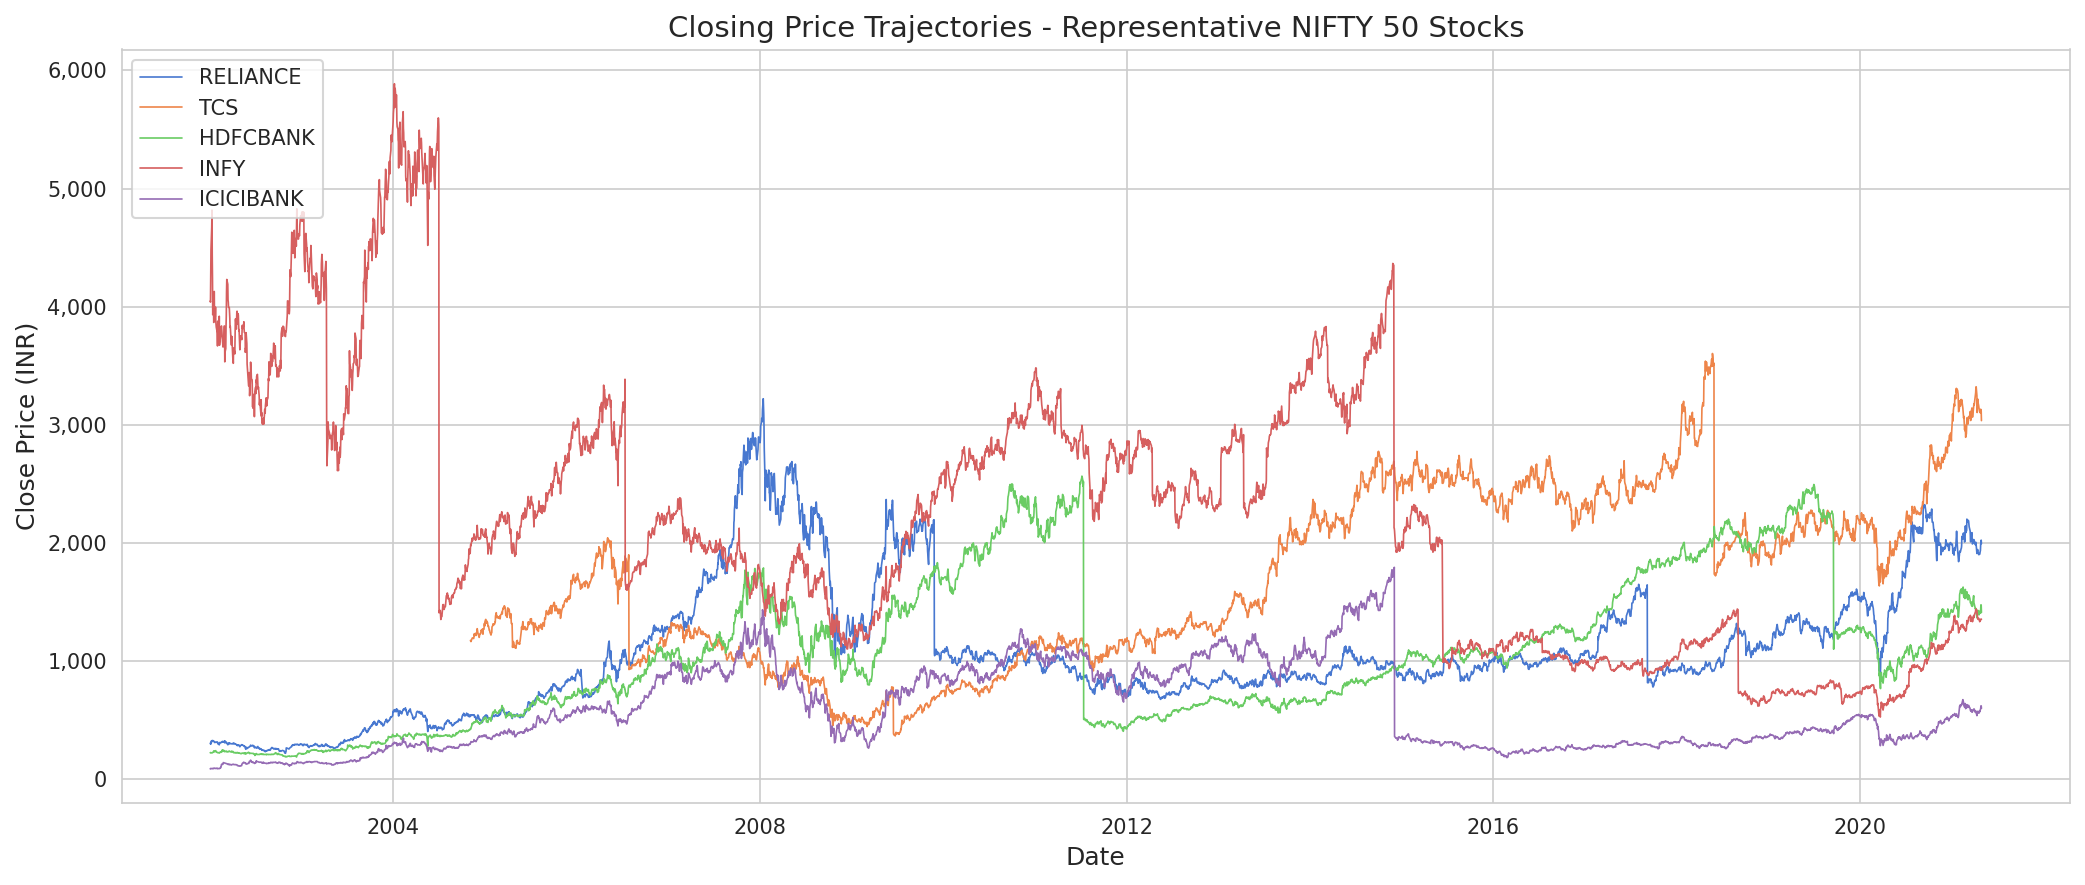

In [75]:
# ---------------------------------------------------------------------------
# 3.1 Closing price trajectories for representative stocks
# ---------------------------------------------------------------------------
representative_stocks = ["RELIANCE", "TCS", "HDFCBANK", "INFY", "ICICIBANK"]
representative_stocks = [
    s for s in representative_stocks if s in df_master["Symbol"].unique()
]

fig, ax = plt.subplots(figsize=(14, 6))
for i, symbol in enumerate(representative_stocks):
    stock_data = df_master[df_master["Symbol"] == symbol]
    ax.plot(stock_data["Date"], stock_data["Close"],
            label=symbol, color=PALETTE[i], linewidth=0.8)

ax.set_title("Closing Price Trajectories - Representative NIFTY 50 Stocks")
ax.set_xlabel("Date")
ax.set_ylabel("Close Price (INR)")
ax.legend(loc="upper left")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
fig.tight_layout()
plt.show()

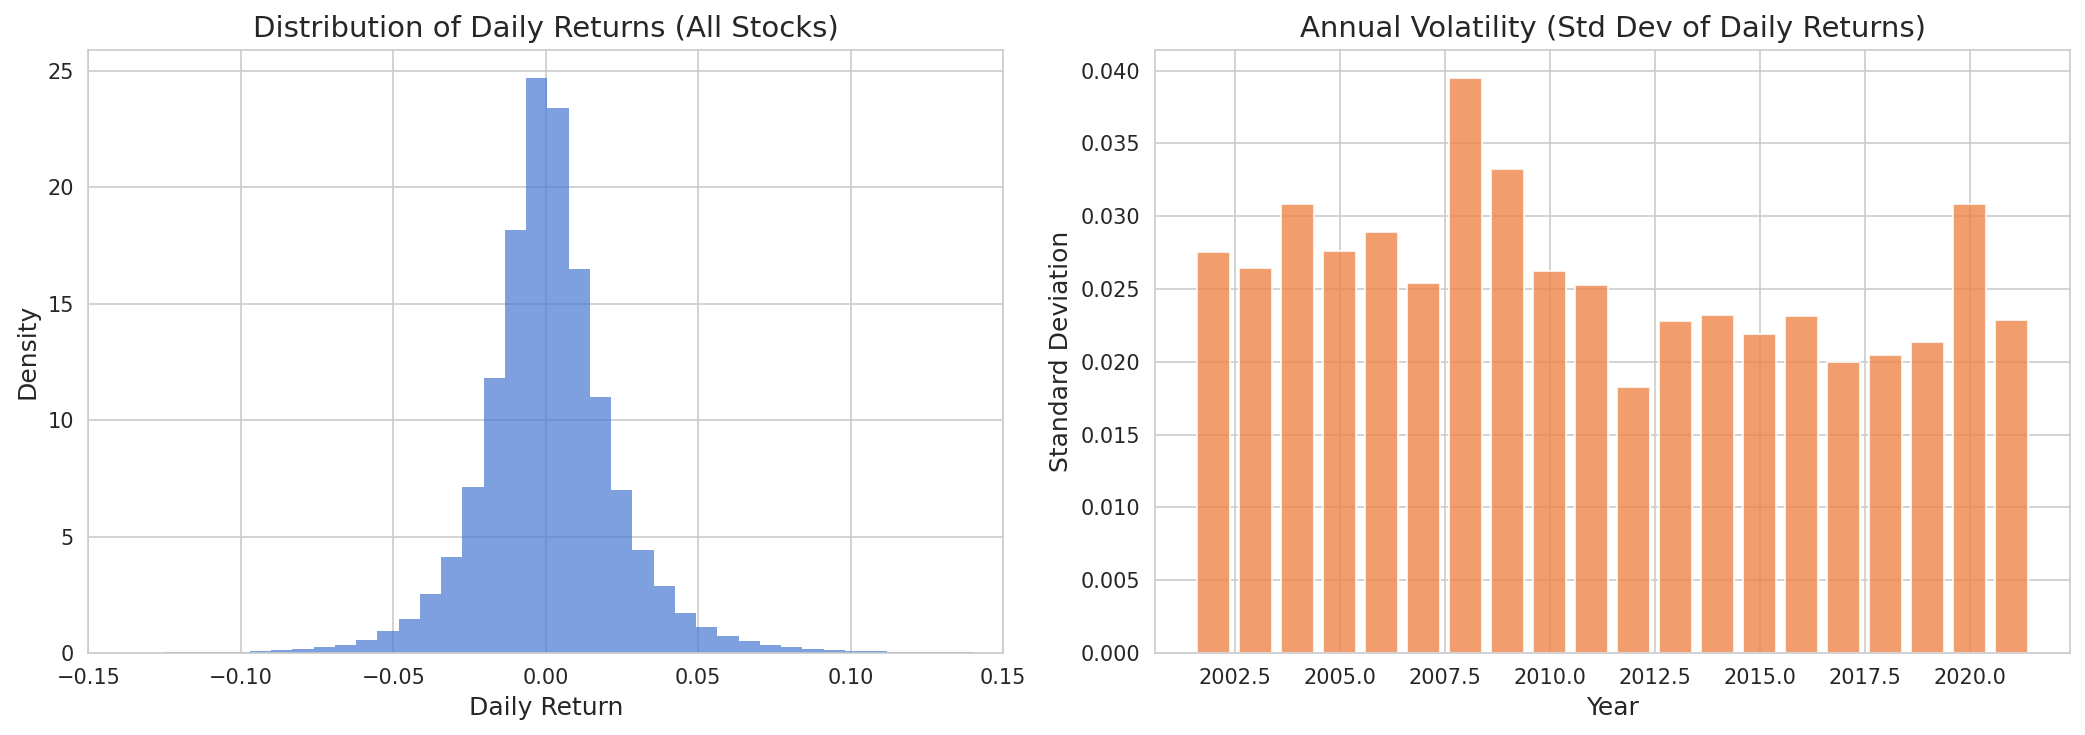

Overall daily return statistics:
count    218327.000000
mean          0.000780
std           0.026232
min          -0.947635
25%          -0.010807
50%           0.000256
75%           0.012013
max           0.446731


In [76]:
# ---------------------------------------------------------------------------
# 3.2 Distribution of daily returns across all stocks
# ---------------------------------------------------------------------------
df_master["Daily_Return_Raw"] = df_master.groupby("Symbol")["Close"].pct_change()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_master["Daily_Return_Raw"].dropna(), bins=200, density=True,
             color=PALETTE[0], alpha=0.7, edgecolor="none")
axes[0].set_title("Distribution of Daily Returns (All Stocks)")
axes[0].set_xlabel("Daily Return")
axes[0].set_ylabel("Density")
axes[0].set_xlim(-0.15, 0.15)

yearly_stats = df_master.dropna(subset=["Daily_Return_Raw"]).groupby(
    df_master["Date"].dt.year
)["Daily_Return_Raw"].agg(["mean", "std"])

axes[1].bar(yearly_stats.index, yearly_stats["std"], color=PALETTE[1], alpha=0.8)
axes[1].set_title("Annual Volatility (Std Dev of Daily Returns)")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Standard Deviation")

fig.tight_layout()
plt.show()

print(f"Overall daily return statistics:")
print(df_master["Daily_Return_Raw"].describe().to_string())

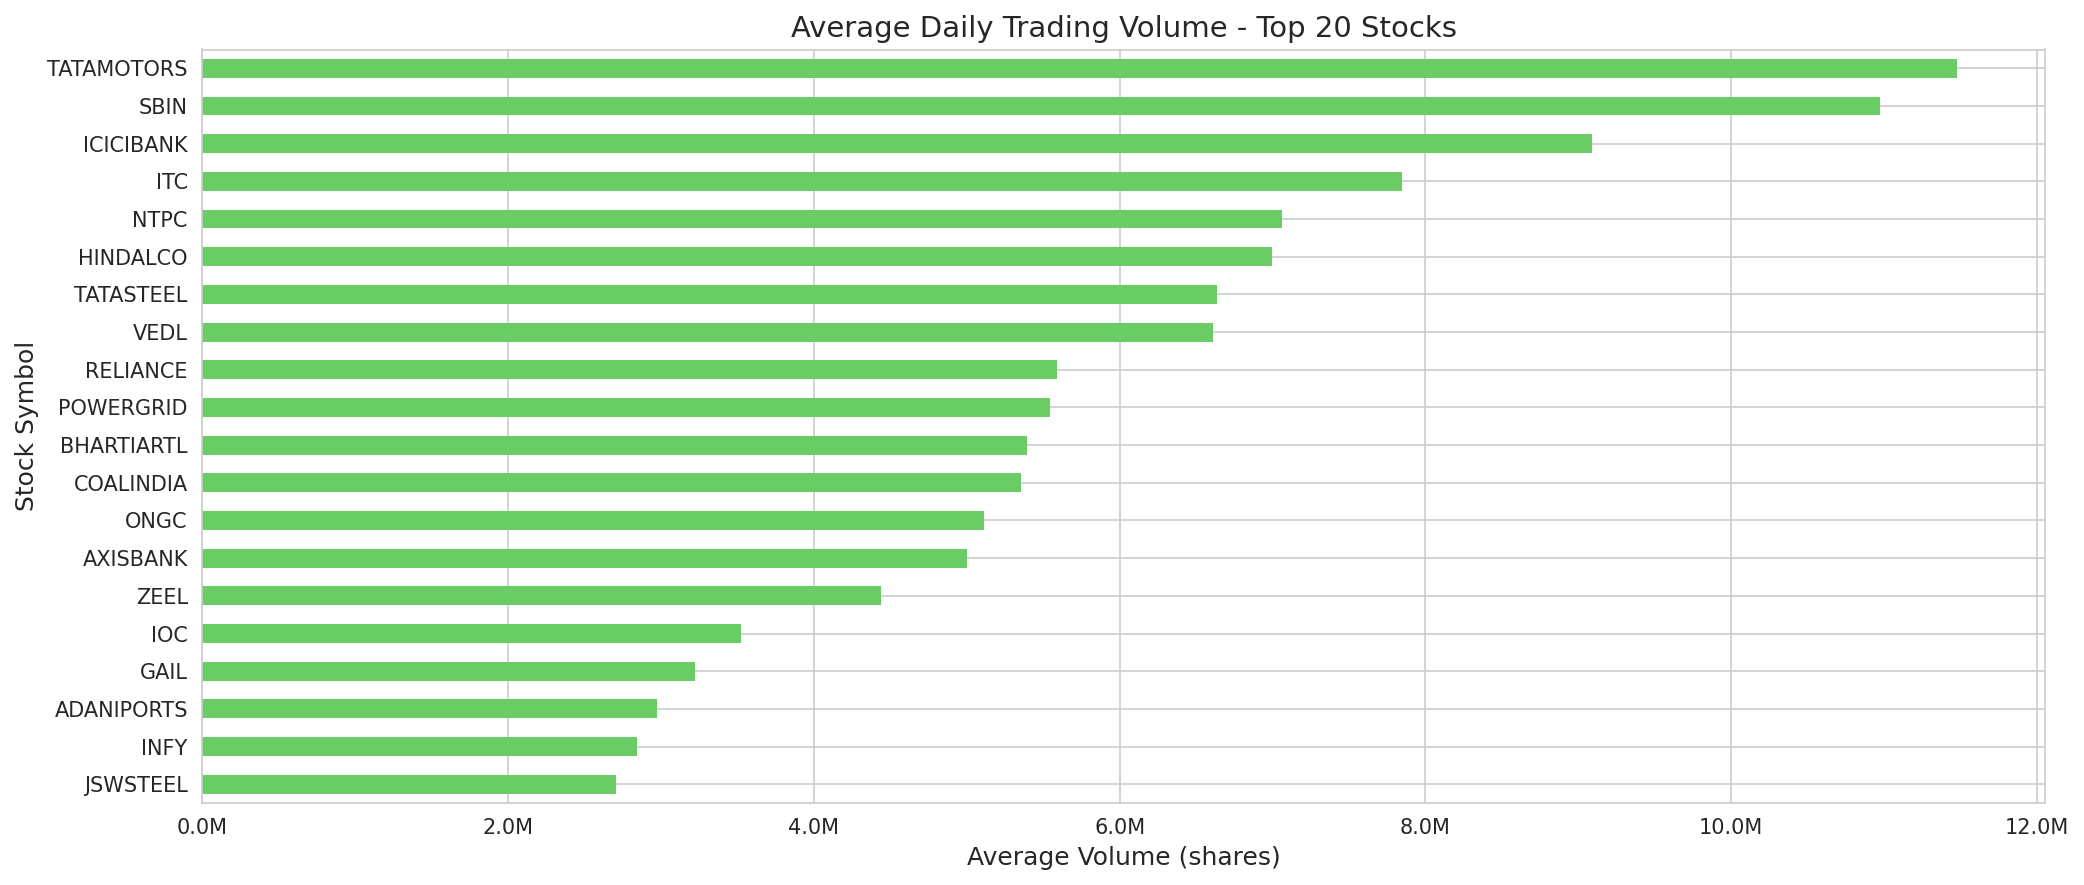

In [77]:
# ---------------------------------------------------------------------------
# 3.3 Average daily volume by stock (top 20)
# ---------------------------------------------------------------------------
avg_volume = df_master.groupby("Symbol")["Volume"].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(14, 6))
avg_volume.head(20).plot(kind="barh", ax=ax, color=PALETTE[2], edgecolor="none")
ax.set_title("Average Daily Trading Volume - Top 20 Stocks")
ax.set_xlabel("Average Volume (shares)")
ax.set_ylabel("Stock Symbol")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))
ax.invert_yaxis()
fig.tight_layout()
plt.show()

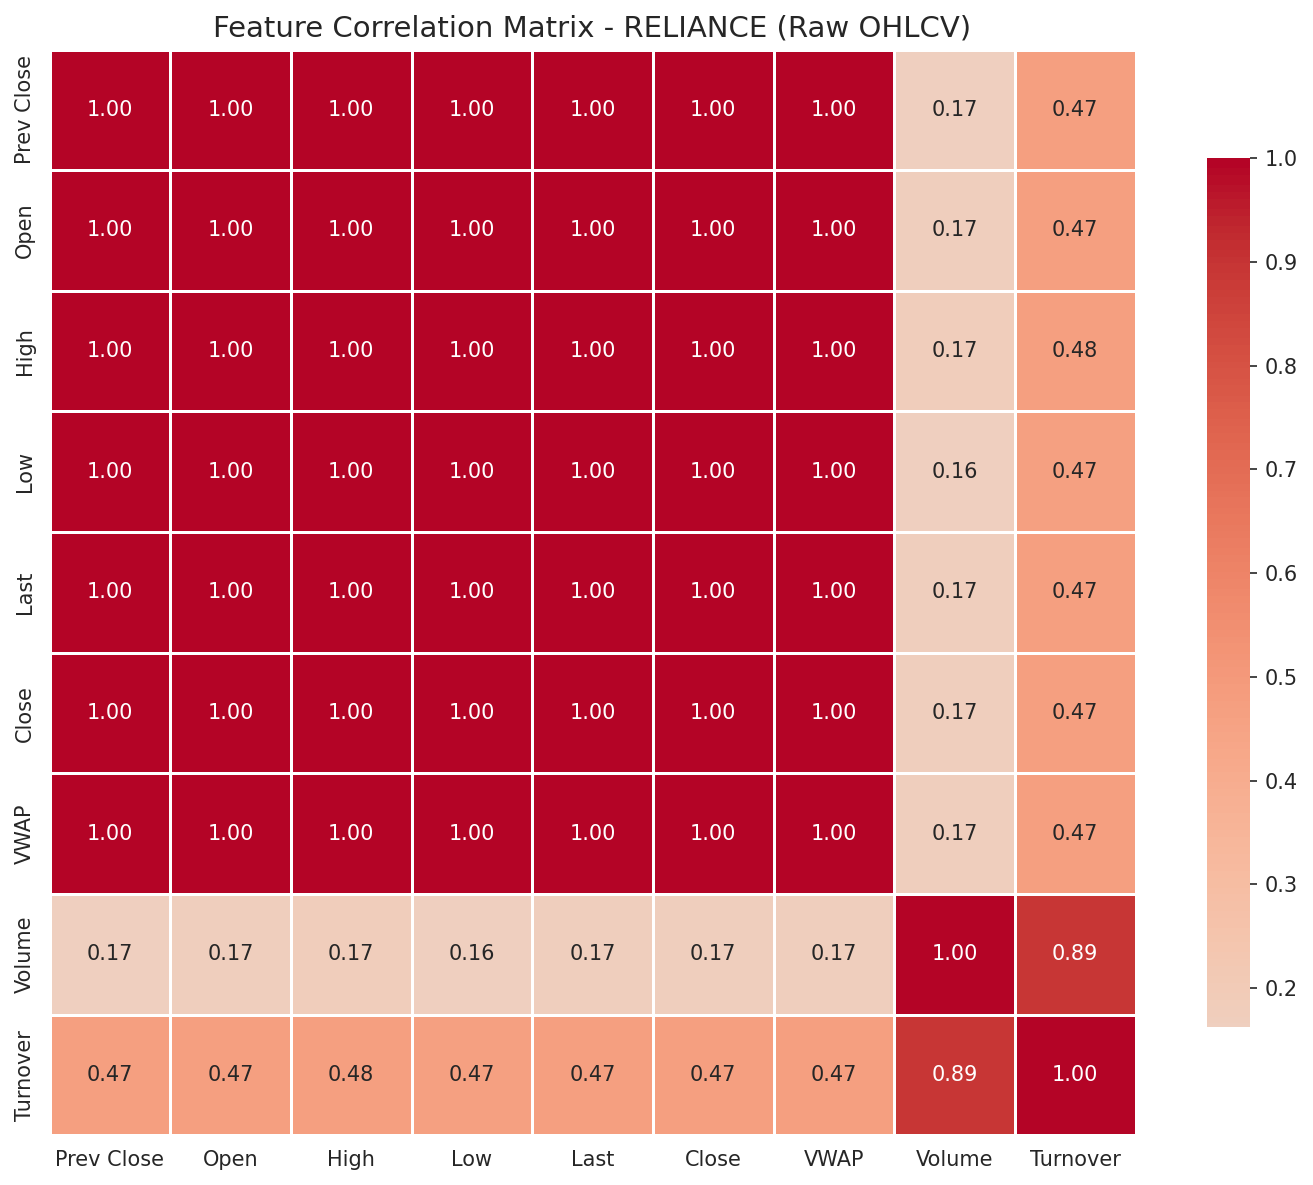

In [78]:
# ---------------------------------------------------------------------------
# 3.4 Correlation heatmap of raw OHLCV features (single stock)
# ---------------------------------------------------------------------------
sample_symbol = (
    representative_stocks[0] if representative_stocks
    else df_master["Symbol"].unique()[0]
)
sample_data = df_master[df_master["Symbol"] == sample_symbol].copy()

raw_numeric_cols_plot = [
    "Prev Close", "Open", "High", "Low", "Last", "Close",
    "VWAP", "Volume", "Turnover",
]
corr_matrix = sample_data[raw_numeric_cols_plot].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, ax=ax, square=True, linewidths=0.5,
            cbar_kws={"shrink": 0.8})
ax.set_title(f"Feature Correlation Matrix - {sample_symbol} (Raw OHLCV)")
fig.tight_layout()
plt.show()

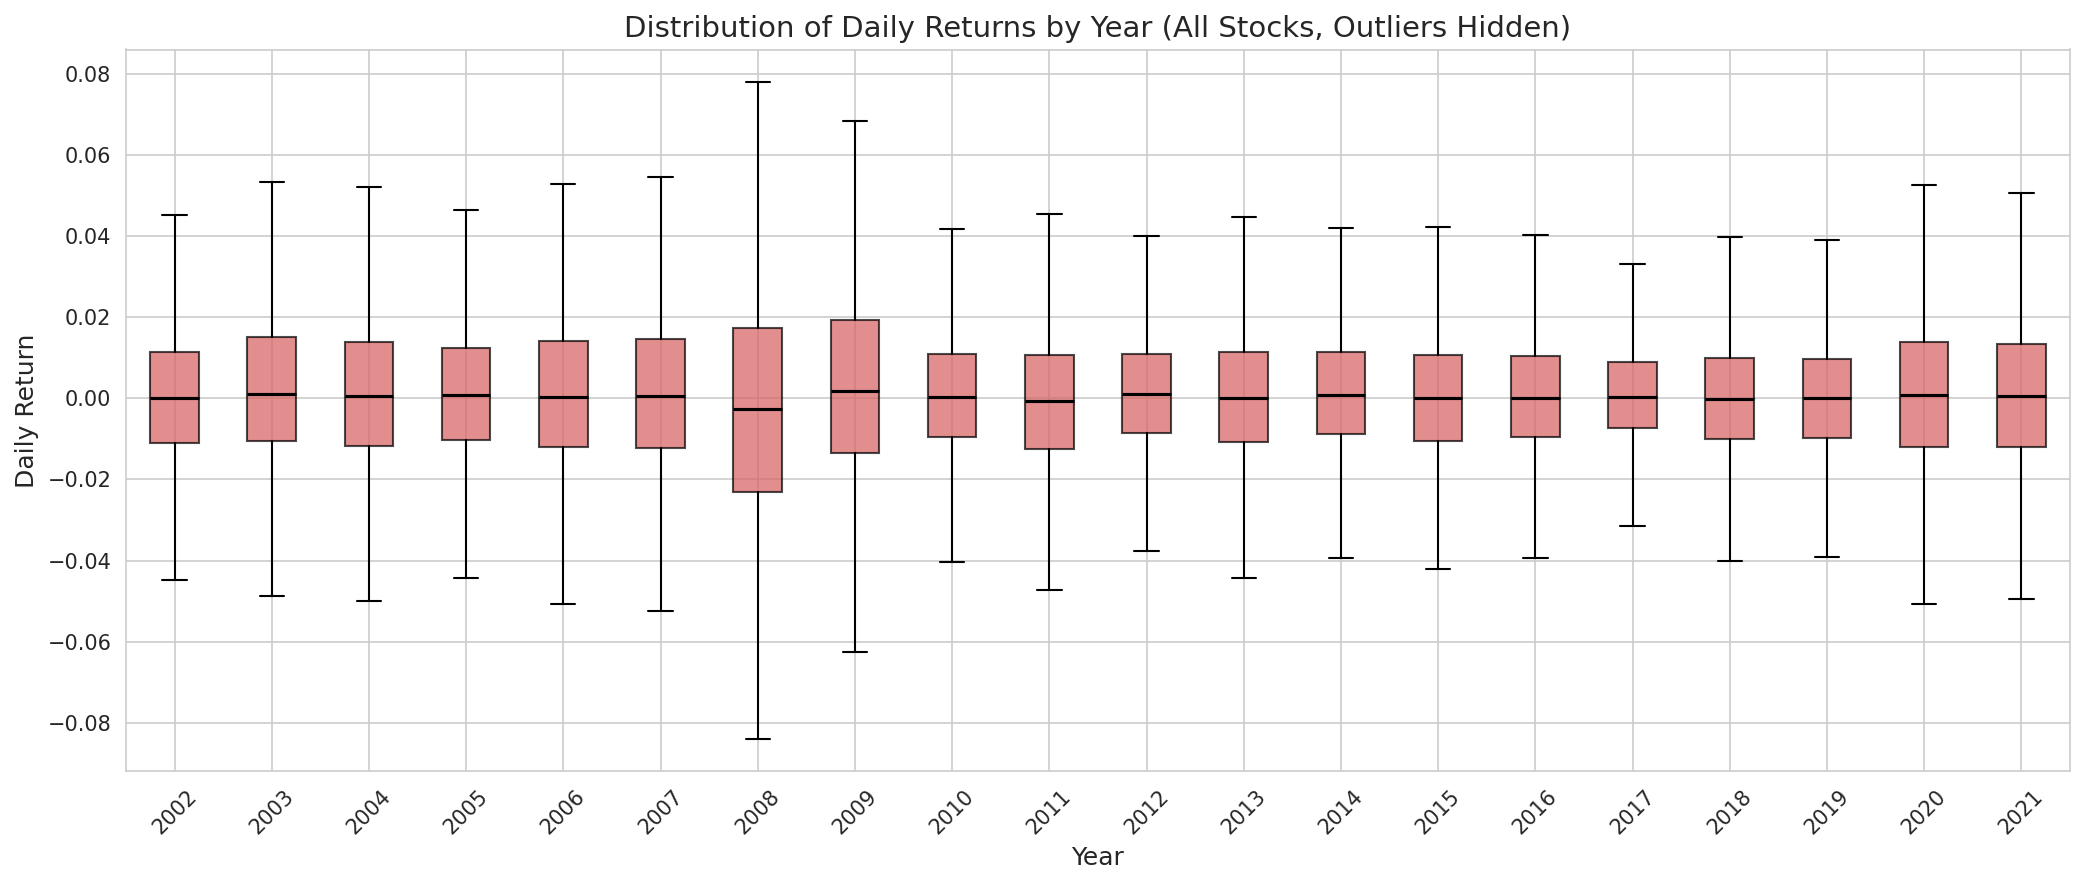

In [79]:
# ---------------------------------------------------------------------------
# 3.5 Yearly return distribution boxplot
# ---------------------------------------------------------------------------
df_master["Year"] = df_master["Date"].dt.year
yearly_data = df_master.dropna(subset=["Daily_Return_Raw"])

fig, ax = plt.subplots(figsize=(14, 6))
years = sorted(yearly_data["Year"].unique())
data_by_year = [
    yearly_data[yearly_data["Year"] == y]["Daily_Return_Raw"].values
    for y in years
]
bp = ax.boxplot(data_by_year, labels=years, patch_artist=True, showfliers=False,
                medianprops={"color": "black", "linewidth": 1.5})
for patch in bp["boxes"]:
    patch.set_facecolor(PALETTE[3])
    patch.set_alpha(0.7)
ax.set_title("Distribution of Daily Returns by Year (All Stocks, Outliers Hidden)")
ax.set_xlabel("Year")
ax.set_ylabel("Daily Return")
plt.xticks(rotation=45)
fig.tight_layout()
plt.show()

### Key Observations from Exploratory Data Analysis

1. **Price scale heterogeneity.** Stock prices vary by orders of magnitude across the
   NIFTY 50 universe (e.g., single-digit to multi-thousand INR). This confirms the
   necessity of normalised/relative features rather than raw price levels for training
   a single generic agent.

2. **Volatility clustering.** Annual volatility spikes visibly during crisis periods
   (the 2008 global financial crisis, the 2020 COVID-19 crash), consistent with the
   well-documented phenomenon of volatility clustering in equity markets. The DQN
   agent must learn to adapt behaviour across calm and turbulent regimes.

3. **Volume concentration.** Trading volume is heavily concentrated in a handful of
   large-cap names. The agent will encounter very different liquidity environments
   across stocks, which the Volume Ratio feature is designed to capture.

4. **Return distribution.** Daily returns exhibit leptokurtosis (fat tails) and
   near-zero mean, consistent with stylised facts of financial returns. Extreme
   events are present in the data and will influence the agent's risk-adjusted
   performance metrics.

---

# 4. Feature Engineering

This section computes 15 engineered technical indicators directly from the raw OHLCV columns.
By calculating these on the fly, the notebook is entirely self-contained and can run directly on the raw Kaggle dataset.

Each feature encodes its own rolling history internally:

| # | Feature | Formula / Description |
|---|---|---|
| 1 | Log_Return | log(Close_t / Close_{t-1}) |
| 2 | Vol_10D | Rolling std of Log_Return, window=10 |
| 3 | Vol_20D | Rolling std of Log_Return, window=20 |
| 4 | Dist_SMA_10 | (Close - SMA_10) / SMA_10 |
| 5 | Dist_SMA_20 | (Close - SMA_20) / SMA_20 |
| 6 | Dist_SMA_50 | (Close - SMA_50) / SMA_50 |
| 7 | RSI_14 | Relative Strength Index, 14-day window |
| 8 | MACD | EMA_12 - EMA_26 |
| 9 | MACD_Signal | EMA_9 of MACD |
| 10 | MACD_Diff | MACD - MACD_Signal |
| 11 | BB_Pband | Bollinger Band %B (20-day, 2 std) |
| 12 | ATR_14 | Average True Range, 14-day window |
| 13 | Volume_Ratio_20 | Volume / SMA_20(Volume) |
| 14 | VWAP_Dist | (Close - VWAP) / VWAP |
| 15 | Deliverable_Pct | Deliverable Volume / Volume |


---

# 5. Sentiment Feature Integration

Sentiment features from Subproblem D are integrated here. Until the real pipeline
is delivered, placeholder zeros are used. The agent's sentiment inputs carry zero
information in this run, which is intentional and safe (equivalent to training a
price-only agent).

| Feature | Derivation |
|---|---|
| `Sentiment_Score` | Mean sentiment polarity per (ticker, date) |
| `Sentiment_Magnitude` | Mean magnitude per (ticker, date) |
| `Article_Count` | Number of articles per (ticker, date) |
| `Sentiment_Rolling_3D` | 3-day rolling mean of Sentiment_Score per ticker |

To switch to real data: set `SENTIMENT_CSV_PATH` in Section 1.1 to the path of
Dhairya's `sentiment_features.csv`. No other changes are needed.

In [80]:
# ---------------------------------------------------------------------------
# 5.1 Load or generate sentiment features
# ---------------------------------------------------------------------------
def generate_placeholder_sentiment(df_with_symbol_date):
    """
    Returns a DataFrame with 'Symbol', 'Date', and all SENTIMENT_COLUMNS
    filled with 0.0. This is a neutral placeholder: the agent sees no
    sentiment signal and behaves as a price-only model.
    """
    placeholder = df_with_symbol_date[["Symbol", "Date"]].copy()
    for col in SENTIMENT_COLUMNS:
        placeholder[col] = 0.0
    return placeholder


def load_real_sentiment(path):
    """
    Loads scored_raw.csv (article-level sentiment) and aggregates it to
    daily frequency per stock, producing the 4 required SENTIMENT_COLUMNS.

    Input schema: date, ticker, headline, category, source,
                  sentiment_score, magnitude

    Output schema: Date, Symbol, Sentiment_Score, Sentiment_Magnitude,
                   Article_Count, Sentiment_Rolling_3D
    """
    df_raw = pd.read_csv(path)

    # Normalise column names to match notebook conventions
    df_raw.rename(columns={"date": "Date", "ticker": "Symbol"}, inplace=True)
    df_raw["Date"] = pd.to_datetime(df_raw["Date"])

    # Aggregate: multiple articles per (Date, Symbol) -> one row
    df_daily = (
        df_raw
        .groupby(["Date", "Symbol"], as_index=False)
        .agg(
            Sentiment_Score=("sentiment_score", "mean"),
            Sentiment_Magnitude=("magnitude", "mean"),
            Article_Count=("headline", "count"),
        )
    )

    # 3-day rolling mean of the daily sentiment score per stock
    df_daily.sort_values(["Symbol", "Date"], inplace=True)
    df_daily["Sentiment_Rolling_3D"] = (
        df_daily
        .groupby("Symbol")["Sentiment_Score"]
        .transform(lambda x: x.rolling(3, min_periods=1).mean())
    )

    return df_daily[["Symbol", "Date"] + SENTIMENT_COLUMNS].reset_index(drop=True)


if SENTIMENT_CSV_PATH is None:
    print("Using placeholder sentiment (zeros). Set SENTIMENT_CSV_PATH for real data.")
    df_sentiment = generate_placeholder_sentiment(df_master[["Symbol", "Date"]])
else:
    print(f"Loading real sentiment data from: {SENTIMENT_CSV_PATH}")
    df_sentiment = load_real_sentiment(SENTIMENT_CSV_PATH)

print(f"Sentiment DataFrame shape: {df_sentiment.shape}")
print(df_sentiment[SENTIMENT_COLUMNS].describe().round(4).to_string())


Loading real sentiment data from: /kaggle/input/datasets/harjapsinghbhatia/sentiment-score/scored_raw.csv
Sentiment DataFrame shape: (30334, 6)
       Sentiment_Score  Sentiment_Magnitude  Article_Count  Sentiment_Rolling_3D
count       30334.0000           30334.0000      30334.000            30334.0000
mean            0.0594               0.1733          1.357                0.0595
std             0.1684               0.2289          0.747                0.1093
min            -0.9000               0.0000          1.000               -0.7583
25%             0.0000               0.0000          1.000                0.0000
50%             0.0000               0.0000          1.000                0.0167
75%             0.0667               0.3000          2.000                0.1000
max             0.9000               1.0000         10.000                0.9000


In [81]:
# ---------------------------------------------------------------------------
# 5.2 Merge sentiment into master DataFrame
# ---------------------------------------------------------------------------
rows_before = len(df_master)

df_master = df_master.merge(
    df_sentiment[["Symbol", "Date"] + SENTIMENT_COLUMNS],
    on=["Symbol", "Date"],
    how="left",
)

assert len(df_master) == rows_before, (
    "Row count changed after sentiment merge -- check join keys."
)

# Days with no news coverage: apply exponential decay (halflife=5 trading days).
# News sentiment decays gradually -- it does not snap to zero.
# With halflife=5: after 5 days the score is at 50%, after 25 days it is at ~3%.
# Any days before the first article for a stock are filled with 0.0 (truly no signal).
df_master.sort_values(["Symbol", "Date"], inplace=True)
df_master[SENTIMENT_COLUMNS] = (
    df_master
    .groupby("Symbol")[SENTIMENT_COLUMNS]
    .transform(lambda x: x.ewm(halflife=5, min_periods=0).mean().fillna(0))
)
df_master.reset_index(drop=True, inplace=True)

null_counts = df_master[SENTIMENT_COLUMNS].isnull().sum()
print("Null counts after fill (should all be 0):")
print(null_counts.to_string())
print(f"\ndf_master now has {len(df_master.columns)} columns.")
print("Sentiment integration complete (EWMA decay, halflife=5 trading days).")


Null counts after fill (should all be 0):
Sentiment_Score         0
Sentiment_Magnitude     0
Article_Count           0
Sentiment_Rolling_3D    0

df_master now has 34 columns.
Sentiment integration complete (EWMA decay, halflife=5 trading days).


---

# 6. Post-Feature Engineering Visualisation

We examine the distributions and relationships of the engineered features to
verify that they are well-behaved (finite, reasonably scaled) and that they
capture distinct aspects of market behaviour.

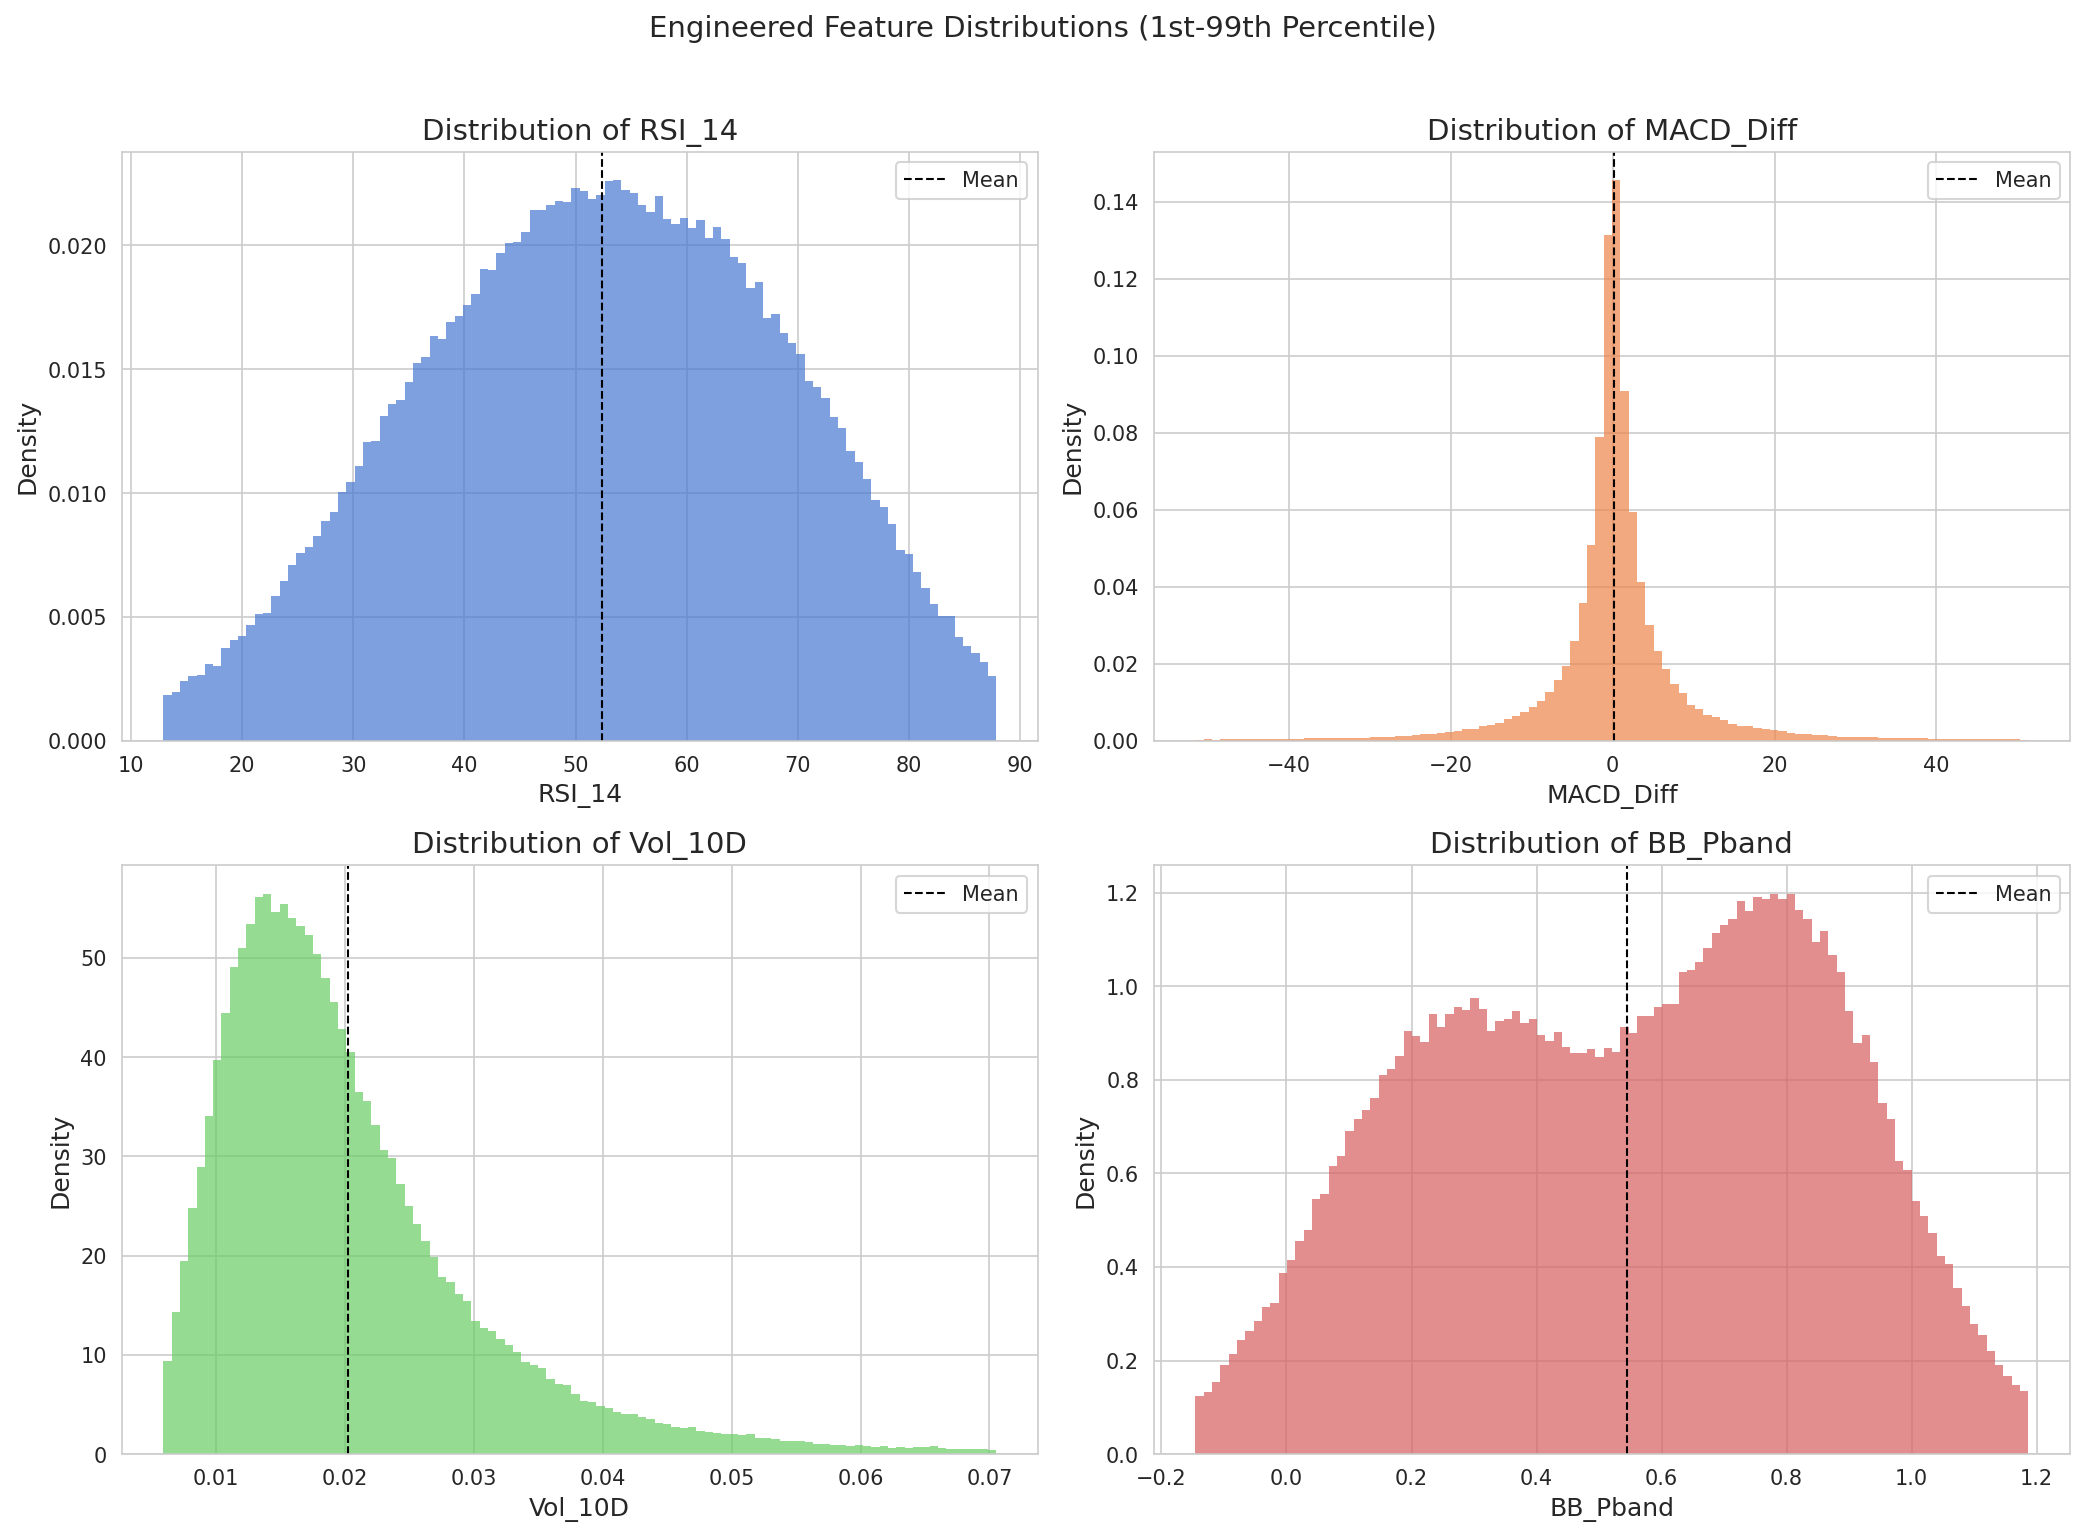

In [82]:
# ---------------------------------------------------------------------------
# 6.1 Distribution of key engineered features
# ---------------------------------------------------------------------------
key_features = ["RSI_14", "MACD_Diff", "Vol_10D", "BB_Pband"]
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, feat, color in zip(axes.flat, key_features, PALETTE[:4]):
    data = df_master[feat].dropna()
    lower, upper = data.quantile(0.01), data.quantile(0.99)
    clipped = data[(data >= lower) & (data <= upper)]
    ax.hist(clipped, bins=100, density=True, color=color, alpha=0.7, edgecolor="none")
    ax.set_title(f"Distribution of {feat}")
    ax.set_xlabel(feat)
    ax.set_ylabel("Density")
    ax.axvline(clipped.mean(), color="black", linestyle="--", linewidth=1, label="Mean")
    ax.legend()

fig.suptitle("Engineered Feature Distributions (1st-99th Percentile)", fontsize=14, y=1.02)
fig.tight_layout()
plt.show()

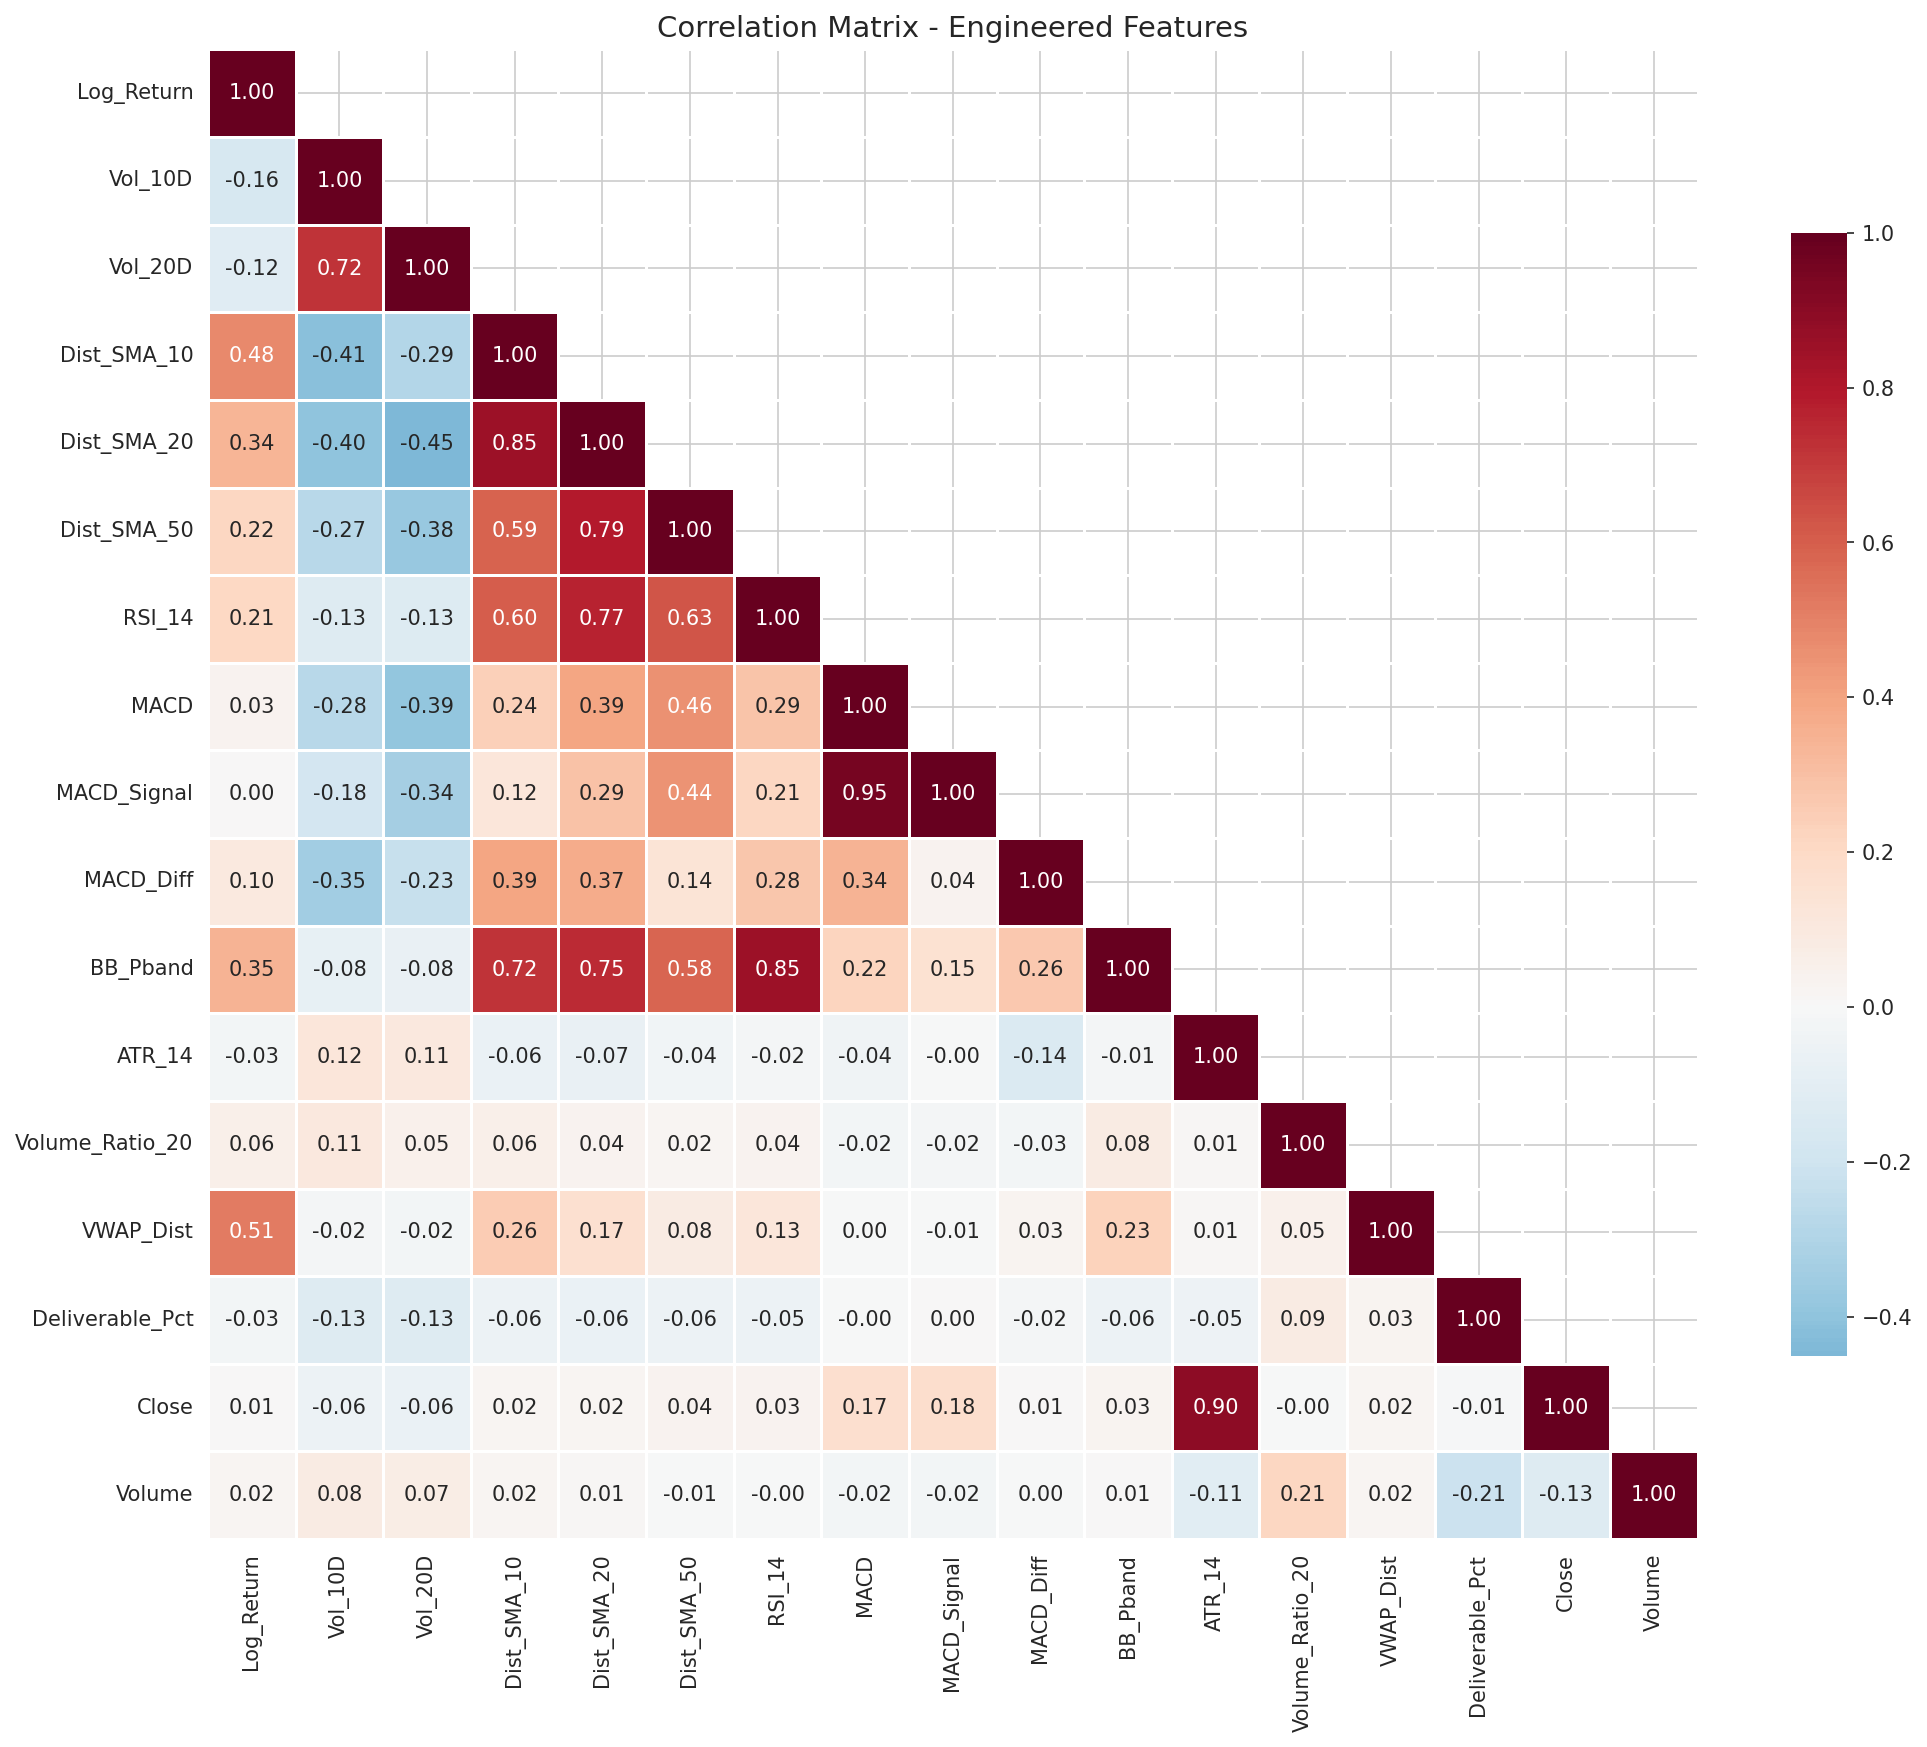

In [83]:
# ---------------------------------------------------------------------------
# 6.2 Correlation matrix of engineered features
# ---------------------------------------------------------------------------
vis_features = ENGINEERED_COLUMNS + ["Close", "Volume"]
corr_eng = df_master[vis_features].corr()

fig, ax = plt.subplots(figsize=(14, 12))
mask = np.triu(np.ones_like(corr_eng, dtype=bool), k=1)
sns.heatmap(corr_eng, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, ax=ax, square=True, linewidths=0.5,
            cbar_kws={"shrink": 0.7})
ax.set_title("Correlation Matrix - Engineered Features")
fig.tight_layout()
plt.show()

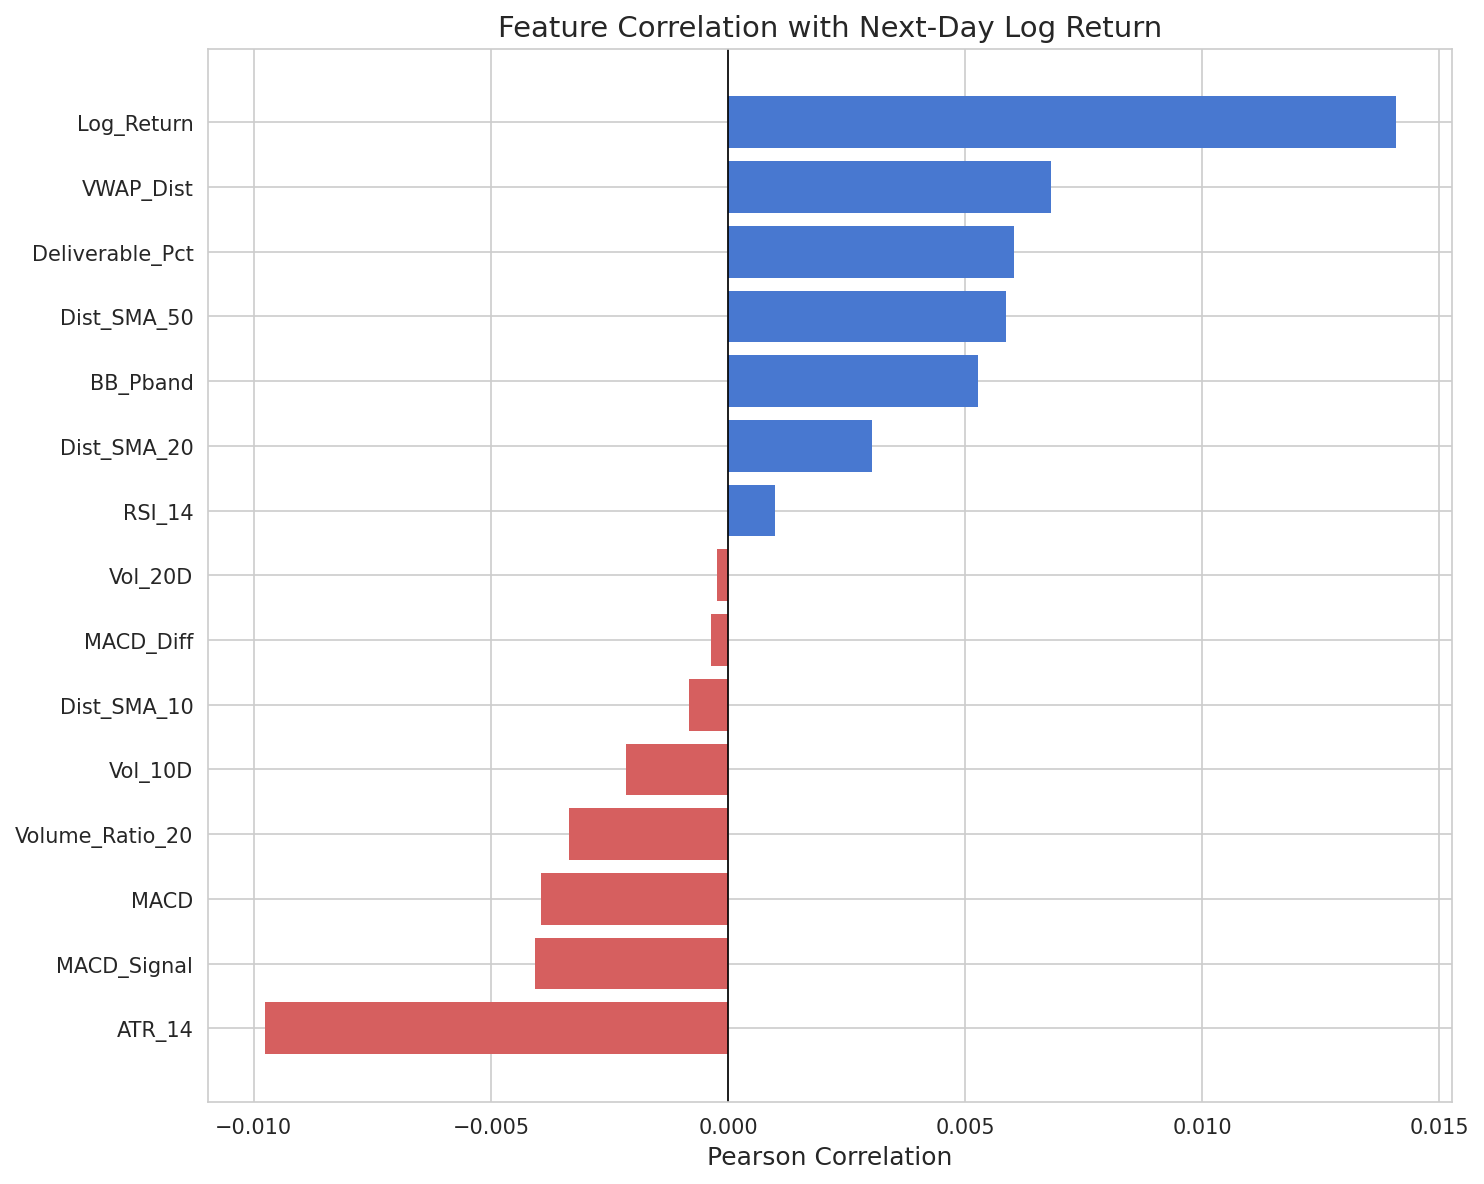

In [84]:
# ---------------------------------------------------------------------------
# 6.3 Feature correlation with next-day returns
# ---------------------------------------------------------------------------
df_master["Next_Day_Return"] = df_master.groupby("Symbol")["Log_Return"].shift(-1)

corr_with_target = (
    df_master[ENGINEERED_COLUMNS + ["Next_Day_Return"]]
    .corr()["Next_Day_Return"]
    .drop("Next_Day_Return")
    .sort_values(ascending=True)
)

fig, ax = plt.subplots(figsize=(10, 8))
colors = [PALETTE[0] if v >= 0 else PALETTE[3] for v in corr_with_target.values]
ax.barh(corr_with_target.index, corr_with_target.values, color=colors, edgecolor="none")
ax.set_title("Feature Correlation with Next-Day Log Return")
ax.set_xlabel("Pearson Correlation")
ax.axvline(0, color="black", linewidth=0.8)
fig.tight_layout()
plt.show()

df_master.drop("Next_Day_Return", axis=1, inplace=True, errors="ignore")

### Key Observations from Engineered Features

1. **RSI distribution.** RSI_14 clusters around 40-60, with tails at the canonical
   overbought (>70) and oversold (<30) thresholds. This suggests the feature has
   discriminative power for identifying extreme sentiment regimes.

2. **MACD and momentum.** MACD_Diff (the histogram component) is approximately
   symmetric around zero, as expected. Its correlation with next-day returns provides
   a weak but directionally useful signal.

3. **Volatility features.** Vol_10D and Vol_20D are right-skewed (volatility is
   bounded below by zero) and exhibit the expected persistence. These will help the
   agent calibrate position sizing during high-volatility regimes.

4. **Feature redundancy.** The correlation matrix reveals expected collinearity among
   price-level features (Open, High, Low, Close, VWAP) and among the MACD family. The
   agent's neural network should learn to exploit these correlations without explicit
   feature selection, but awareness of this structure is important for interpretation.

---

# 7. Data Preparation for Reinforcement Learning

This section prepares the data for the trading environment by:
1. Confirming the final feature column list (30 features, 31-D observation).
2. Splitting data chronologically per stock into train/validation/test sets.
3. Fitting a z-score normaliser (StandardScaler) on training data only, then
   transforming all three splits to prevent lookahead bias.

In [85]:
# ---------------------------------------------------------------------------
# 7.1 Final state feature columns
# ---------------------------------------------------------------------------
# FEATURE_COLUMNS and OBS_DIM were defined in Section 2.1.
# Confirm all feature columns are present in df_master.
missing_features = [c for c in FEATURE_COLUMNS if c not in df_master.columns]
if missing_features:
    raise ValueError(f"Feature columns missing from df_master: {missing_features}")

print(f"State features ({len(FEATURE_COLUMNS)} total):")
for i, f in enumerate(FEATURE_COLUMNS, 1):
    print(f"  {i:2d}. {f}")
print(f"\nObservation dimension: {len(FEATURE_COLUMNS)} features + 1 position flag = {OBS_DIM}")
print(f"\nThis is the v2 state space: a single feature row per timestep.")
print(f"Previous v1 state space was: 30 days x 30 features + 1 = 901 dimensions.")

State features (30 total):
   1. Prev Close
   2. Open
   3. High
   4. Low
   5. Last
   6. Close
   7. VWAP
   8. Volume
   9. Turnover
  10. Trades
  11. Deliverable Volume
  12. Log_Return
  13. Vol_10D
  14. Vol_20D
  15. Dist_SMA_10
  16. Dist_SMA_20
  17. Dist_SMA_50
  18. RSI_14
  19. MACD
  20. MACD_Signal
  21. MACD_Diff
  22. BB_Pband
  23. ATR_14
  24. Volume_Ratio_20
  25. VWAP_Dist
  26. Deliverable_Pct
  27. Sentiment_Score
  28. Sentiment_Magnitude
  29. Article_Count
  30. Sentiment_Rolling_3D

Observation dimension: 30 features + 1 position flag = 31

This is the v2 state space: a single feature row per timestep.
Previous v1 state space was: 30 days x 30 features + 1 = 901 dimensions.


In [86]:
# ---------------------------------------------------------------------------
# 7.2 Chronological train/val/test split per stock
# ---------------------------------------------------------------------------
train_frames = []
val_frames = []
test_frames = []

for symbol in df_master["Symbol"].unique():
    stock_df = df_master[df_master["Symbol"] == symbol].copy()
    stock_df = stock_df.sort_values("Date").reset_index(drop=True)

    n = len(stock_df)
    train_end = int(n * TRAIN_RATIO)
    val_end = int(n * (TRAIN_RATIO + VAL_RATIO))

    train_frames.append(stock_df.iloc[:train_end])
    val_frames.append(stock_df.iloc[train_end:val_end])
    test_frames.append(stock_df.iloc[val_end:])

df_train = pd.concat(train_frames, ignore_index=True)
df_val = pd.concat(val_frames, ignore_index=True)
df_test = pd.concat(test_frames, ignore_index=True)

print(f"Data split complete:")
print(f"  Training set:   {len(df_train):>8,} rows ({len(df_train)/len(df_master):.1%})")
print(f"  Validation set: {len(df_val):>8,} rows ({len(df_val)/len(df_master):.1%})")
print(f"  Test set:       {len(df_test):>8,} rows ({len(df_test)/len(df_master):.1%})")

for name, split_df in [("Train", df_train), ("Val", df_val), ("Test", df_test)]:
    print(f"  {name} date range: "
          f"{split_df['Date'].min().date()} to {split_df['Date'].max().date()}")

Data split complete:
  Training set:    152,835 rows (70.0%)
  Validation set:   32,764 rows (15.0%)
  Test set:         32,777 rows (15.0%)
  Train date range: 2002-01-01 to 2018-03-26
  Val date range: 2015-07-06 to 2019-10-16
  Test date range: 2018-06-01 to 2021-04-30


In [87]:
# ---------------------------------------------------------------------------
# 7.3 Z-score normalisation (fit on training data only)
# ---------------------------------------------------------------------------
scaler = StandardScaler()

# Replace any inf values with NaN before fitting.
for split_df in [df_train, df_val, df_test]:
    split_df[FEATURE_COLUMNS] = split_df[FEATURE_COLUMNS].replace(
        [np.inf, -np.inf], np.nan
    )

# Fit scaler on training data only.
train_feature_values = df_train[FEATURE_COLUMNS].fillna(df_train[FEATURE_COLUMNS].mean())
scaler.fit(train_feature_values)

# Transform all splits.
df_train_scaled = df_train.copy()
df_val_scaled = df_val.copy()
df_test_scaled = df_test.copy()

train_col_means = df_train[FEATURE_COLUMNS].mean()
for split_df in [df_train_scaled, df_val_scaled, df_test_scaled]:
    filled = split_df[FEATURE_COLUMNS].fillna(train_col_means)
    split_df[FEATURE_COLUMNS] = scaler.transform(filled)

# Preserve raw Close prices for reward computation in the environment.
# The scaler overwrites the Close column with a normalised value;
# Raw_Close stores the original price before scaling.
df_train_scaled["Raw_Close"] = df_train["Close"].values
df_val_scaled["Raw_Close"] = df_val["Close"].values
df_test_scaled["Raw_Close"] = df_test["Close"].values

print("Z-score normalisation applied (fit on training data only).")
print(f"\nTraining set feature statistics (post-normalisation):")
print(df_train_scaled[FEATURE_COLUMNS].describe().loc[["mean", "std"]].round(4).to_string())

Z-score normalisation applied (fit on training data only).

Training set feature statistics (post-normalisation):
      Prev Close  Open  High  Low  Last  Close  VWAP  Volume  Turnover  Trades  Deliverable Volume  Log_Return  Vol_10D  Vol_20D  Dist_SMA_10  Dist_SMA_20  Dist_SMA_50  RSI_14  MACD  MACD_Signal  MACD_Diff  BB_Pband  ATR_14  Volume_Ratio_20  VWAP_Dist  Deliverable_Pct  Sentiment_Score  Sentiment_Magnitude  Article_Count  Sentiment_Rolling_3D
mean        -0.0  -0.0  -0.0 -0.0   0.0   -0.0   0.0     0.0       0.0    -0.0                 0.0        -0.0      0.0      0.0         -0.0          0.0          0.0    -0.0  -0.0         -0.0       -0.0      -0.0     0.0             -0.0        0.0             -0.0             -0.0                 -0.0            0.0                  -0.0
std          1.0   1.0   1.0  1.0   1.0    1.0   1.0     1.0       1.0     1.0                 1.0         1.0      1.0      1.0          1.0          1.0          1.0     1.0   1.0          1.0    

---

# 8. Trading Environment (NiftyTradingEnvV2)

The trading environment uses the v2 design by Adithyasai (sub-problem B).
Key differences from the old environment:

- **State:** One feature row per timestep (31-D) instead of a 30-day rolling
  window (901-D).
- **Lookahead-bias prevention:** The agent's action at step t is decided using
  yesterday's feature row (t-1), and reward is the return from yesterday's close
  to today's close. Today's price is never visible before the action is taken.
- **Actions:** Discrete(3): 0=Sell, 1=Hold, 2=Buy.

Two classes are defined:
1. **NiftyTradingEnvV2** -- operates on a single stock's data. Used for evaluation.
2. **MultiStockTradingEnvV2** -- wraps multiple NiftyTradingEnvV2 instances, randomly
   selecting a different stock on each episode reset. Used for training the generic agent.

In [88]:
# ---------------------------------------------------------------------------
# 8.1 NiftyTradingEnvV2
#     (inlined from nifty-rl-env/nifty_trading_env_v2.py)
# ---------------------------------------------------------------------------
class NiftyTradingEnvV2(gym.Env):
    """
    Gymnasium environment trading ONE stock, using Nitesh's engineered
    features plus Dhairya's sentiment features as the state.

    The state at each step is a single feature row from yesterday
    (current_step - 1), appended with the current position flag.
    This prevents lookahead bias: the agent never sees today's price
    before deciding the action that will be executed at today's open.

    Parameters
    ----------
    df : pd.DataFrame
        Must contain 'Date', 'Close', 'Raw_Close', and every column
        in feature_cols. Rows must be sorted by Date ascending.
    feature_cols : list of str
        Columns to include in the observation (normalised features).
    initial_capital : float
    transaction_cost : float
    """

    metadata = {"render_modes": ["human"]}

    def __init__(
        self,
        df,
        feature_cols,
        initial_capital=INITIAL_PORTFOLIO_VALUE,
        transaction_cost=TRANSACTION_COST,
    ):
        super().__init__()

        missing = set(feature_cols) - set(df.columns)
        if missing:
            raise ValueError(f"df is missing feature columns: {missing}")
        if df[feature_cols].isnull().any().any():
            raise ValueError("df contains nulls in feature columns -- clean before use.")

        self.df = df.reset_index(drop=True)
        self.feature_cols = feature_cols
        self.initial_capital = initial_capital
        self.transaction_cost = transaction_cost

        # Actions: 0=Sell, 1=Hold, 2=Buy
        self.action_space = spaces.Discrete(3)

        # Observation: one feature row + position flag
        obs_len = len(feature_cols) + 1
        self.observation_space = spaces.Box(
            low=-np.inf, high=np.inf, shape=(obs_len,), dtype=np.float32
        )

        self.current_step = 0
        self.position = 0
        self.portfolio_value = 0.0
        self._trade_log = []

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        # Start at step 1 (not 0) because step() always looks at
        # current_step - 1 for the observation and reference price.
        self.current_step = 1
        self.position = 0
        self.portfolio_value = self.initial_capital
        self._trade_log = []
        return self._get_observation(), self._get_info()

    def step(self, action):
        assert self.action_space.contains(action), f"Invalid action: {action}"

        close_col = "Raw_Close" if "Raw_Close" in self.df.columns else "Close"
        price_yesterday = self.df.loc[self.current_step - 1, close_col]
        price_today = self.df.loc[self.current_step, close_col]

        trade_cost = 0.0
        if action == 2 and self.position == 0:    # Buy
            self.position = 1
            trade_cost = self.transaction_cost * self.portfolio_value
        elif action == 0 and self.position == 1:  # Sell
            self.position = 0
            trade_cost = self.transaction_cost * self.portfolio_value
        # action == 1 (Hold) or redundant Buy/Sell is a no-op.

        daily_return = (price_today - price_yesterday) / price_yesterday
        pnl = self.portfolio_value * daily_return if self.position == 1 else 0.0

        self.portfolio_value = self.portfolio_value + pnl - trade_cost
        reward = (pnl - trade_cost) / self.initial_capital

        self._trade_log.append({
            "step": self.current_step,
            "action": action,
            "position": self.position,
            "price": price_today,
            "portfolio_value": self.portfolio_value,
        })

        self.current_step += 1
        terminated = self.current_step >= len(self.df) - 1
        truncated = False

        return self._get_observation(), reward, terminated, truncated, self._get_info()

    def render(self):
        print(
            f"Step: {self.current_step:>5} | "
            f"Position: {'LONG' if self.position == 1 else 'FLAT':>4} | "
            f"Portfolio Value: {self.portfolio_value:,.2f}"
        )

    def _get_observation(self):
        row = self.df.loc[
            self.current_step - 1, self.feature_cols
        ].values.astype(np.float32)
        return np.concatenate([row, [float(self.position)]]).astype(np.float32)

    def _get_info(self):
        idx = min(self.current_step, len(self.df) - 1)
        close_col = "Raw_Close" if "Raw_Close" in self.df.columns else "Close"
        return {
            "step": self.current_step,
            "position": self.position,
            "portfolio_value": self.portfolio_value,
            "price": self.df.loc[idx, close_col],
        }

    def get_trade_log(self):
        return pd.DataFrame(self._trade_log)


print("NiftyTradingEnvV2 defined.")

NiftyTradingEnvV2 defined.


In [89]:
# ---------------------------------------------------------------------------
# 8.2 MultiStockTradingEnvV2
#     Wraps one NiftyTradingEnvV2 per stock; randomly selects a stock on
#     each episode reset to train a generic cross-stock agent.
# ---------------------------------------------------------------------------
class MultiStockTradingEnvV2(gym.Env):
    """
    Wraps multiple NiftyTradingEnvV2 instances, randomly selecting a stock
    on each episode reset. This trains a single generic DQN agent that
    generalises across the full NIFTY 50 universe.

    Parameters
    ----------
    stock_data_dict : dict[str, pd.DataFrame]
        Mapping from stock symbol to its normalised DataFrame.
        Each DataFrame must contain FEATURE_COLUMNS and 'Raw_Close'.
    feature_cols : list of str
    """

    metadata = {"render_modes": []}

    def __init__(self, stock_data_dict, feature_cols):
        super().__init__()
        self.feature_cols = feature_cols

        # Create one NiftyTradingEnvV2 per stock (skip stocks with < 10 rows).
        self.stock_envs = {}
        for symbol, data in stock_data_dict.items():
            if len(data) >= 10:
                self.stock_envs[symbol] = NiftyTradingEnvV2(
                    df=data,
                    feature_cols=feature_cols,
                )

        self.stock_symbols = list(self.stock_envs.keys())
        assert len(self.stock_symbols) > 0, "No stocks with sufficient data."

        # All sub-environments share the same observation and action space.
        ref_env = self.stock_envs[self.stock_symbols[0]]
        self.observation_space = ref_env.observation_space
        self.action_space = ref_env.action_space

        self._current_env = None
        self._current_symbol = None

    def reset(self, *, seed=None, options=None):
        super().reset(seed=seed)
        idx = self.np_random.integers(0, len(self.stock_symbols))
        self._current_symbol = self.stock_symbols[idx]
        self._current_env = self.stock_envs[self._current_symbol]
        obs, info = self._current_env.reset(seed=seed)
        info["symbol"] = self._current_symbol
        return obs, info

    def step(self, action):
        obs, reward, terminated, truncated, info = self._current_env.step(action)
        info["symbol"] = self._current_symbol
        return obs, reward, terminated, truncated, info


print("MultiStockTradingEnvV2 defined.")

MultiStockTradingEnvV2 defined.


In [90]:
# ---------------------------------------------------------------------------
# 8.3 Build per-stock DataFrames for each split
# ---------------------------------------------------------------------------
def build_stock_dict(df_scaled):
    """Build a {symbol: DataFrame} dict from a concatenated scaled DataFrame."""
    stock_dict = {}
    for symbol in df_scaled["Symbol"].unique():
        stock_df = (
            df_scaled[df_scaled["Symbol"] == symbol]
            .sort_values("Date")
            .reset_index(drop=True)
        )
        if len(stock_df) >= 10:
            stock_dict[symbol] = stock_df
    return stock_dict


train_stock_dict = build_stock_dict(df_train_scaled)
val_stock_dict = build_stock_dict(df_val_scaled)
test_stock_dict = build_stock_dict(df_test_scaled)

print(f"Stocks with sufficient data:")
print(f"  Training:   {len(train_stock_dict)} stocks")
print(f"  Validation: {len(val_stock_dict)} stocks")
print(f"  Test:       {len(test_stock_dict)} stocks")

Stocks with sufficient data:
  Training:   49 stocks
  Validation: 49 stocks
  Test:       49 stocks


In [91]:
# ---------------------------------------------------------------------------
# 8.4 Validate environment with SB3 check_env
# ---------------------------------------------------------------------------
sample_symbol = list(train_stock_dict.keys())[0]
sample_env = NiftyTradingEnvV2(
    df=train_stock_dict[sample_symbol],
    feature_cols=FEATURE_COLUMNS,
)

try:
    sb3_check_env(sample_env, warn=True)
    print(f"[PASS] Environment passed SB3 check_env validation.")
except Exception as e:
    print(f"[FAIL] Environment validation error: {e}")

print(f"  Observation space: {sample_env.observation_space}")
print(f"  Action space:      {sample_env.action_space}")
print(f"  Observation dim:   {sample_env.observation_space.shape[0]}")

obs, info = sample_env.reset()
print(f"  Reset observation shape: {obs.shape}")
obs, reward, term, trunc, info = sample_env.step(1)
print(f"  Step observation shape: {obs.shape}, reward: {reward:.6f}")
del sample_env

[PASS] Environment passed SB3 check_env validation.
  Observation space: Box(-inf, inf, (31,), float32)
  Action space:      Discrete(3)
  Observation dim:   31
  Reset observation shape: (31,)
  Step observation shape: (31,), reward: 0.000000


---

# 9. Hyperparameter Optimisation

Rather than hardcoding hyperparameter values, we perform a randomised search over
the most impactful DQN parameters. Each candidate configuration is trained for a
short run, then evaluated on the validation set using the Sharpe Ratio as the
selection criterion.

The search space covers:
- **Learning rate (alpha):** controls gradient step size
- **Discount factor (gamma):** controls the agent's time horizon
- **Exploration fraction:** portion of training devoted to epsilon decay
- **Batch size:** number of transitions sampled per gradient update

To keep computation feasible within Kaggle resource limits, we use a small number
of training timesteps per candidate and sample a subset of configurations from the
full grid.

In [92]:
# ---------------------------------------------------------------------------
# 9.1 Evaluation helper for hyperparameter search
# ---------------------------------------------------------------------------
def evaluate_agent_on_validation(model, val_stock_dict, feature_cols, n_episodes=5):
    """
    Run the agent on a random sample of validation stocks and return
    the average Sharpe Ratio.
    """
    sharpe_ratios = []
    symbols = list(val_stock_dict.keys())
    if len(symbols) == 0:
        return 0.0

    sample_symbols = np.random.choice(
        symbols, size=min(n_episodes, len(symbols)), replace=False
    )

    for symbol in sample_symbols:
        env = NiftyTradingEnvV2(
            df=val_stock_dict[symbol],
            feature_cols=feature_cols,
        )
        obs, _ = env.reset()
        daily_returns = []
        done = False

        while not done:
            action, _ = model.predict(obs, deterministic=True)
            obs, reward, terminated, truncated, info = env.step(int(action))
            daily_returns.append(reward)
            done = terminated or truncated

        if len(daily_returns) > 1:
            daily_returns = np.array(daily_returns)
            std = np.std(daily_returns, ddof=1)
            if std > 0:
                sharpe = (np.mean(daily_returns) / std) * np.sqrt(TRADING_DAYS_PER_YEAR)
            else:
                sharpe = 0.0
            sharpe_ratios.append(sharpe)

    return np.mean(sharpe_ratios) if sharpe_ratios else 0.0


print("Validation evaluation function defined.")

Validation evaluation function defined.


In [93]:
# ---------------------------------------------------------------------------
# 9.2 Hyperparameter search
# ---------------------------------------------------------------------------
HP_SEARCH_TIMESTEPS = 10_000

param_grid = {
    "learning_rate": [1e-5, 5e-5, 1e-4, 5e-4, 1e-3],
    "gamma": [0.95, 0.97, 0.99],
    "exploration_fraction": [0.1, 0.2, 0.3],
    "batch_size": [32, 64, 128],
}

total_combos = 1
for v in param_grid.values():
    total_combos *= len(v)
print(f"Total grid combinations: {total_combos}")

N_SEARCH_CANDIDATES = min(15, total_combos)
np.random.seed(RANDOM_SEED)

candidates = []
for _ in range(N_SEARCH_CANDIDATES):
    config = {k: np.random.choice(v) for k, v in param_grid.items()}
    config["learning_rate"] = float(config["learning_rate"])
    config["gamma"] = float(config["gamma"])
    config["exploration_fraction"] = float(config["exploration_fraction"])
    config["batch_size"] = int(config["batch_size"])
    candidates.append(config)

print(f"Evaluating {N_SEARCH_CANDIDATES} random configurations...")
print("-" * 80)

results = []
train_env_hp = MultiStockTradingEnvV2(train_stock_dict, FEATURE_COLUMNS)

for i, config in enumerate(candidates):
    print(f"  Candidate {i+1}/{N_SEARCH_CANDIDATES}: lr={config['learning_rate']:.1e}, "
          f"gamma={config['gamma']:.2f}, explore={config['exploration_fraction']:.1f}, "
          f"batch={config['batch_size']}")

    try:
        model = DQN(
            policy="MlpPolicy",
            env=train_env_hp,
            learning_rate=config["learning_rate"],
            gamma=config["gamma"],
            buffer_size=50_000,
            batch_size=config["batch_size"],
            exploration_fraction=config["exploration_fraction"],
            exploration_final_eps=0.05,
            verbose=0,
            seed=RANDOM_SEED,
        )
        model.learn(total_timesteps=HP_SEARCH_TIMESTEPS)

        val_sharpe = evaluate_agent_on_validation(
            model, val_stock_dict, FEATURE_COLUMNS
        )
        config["val_sharpe"] = val_sharpe
        results.append(config)
        print(f"    -> Validation Sharpe: {val_sharpe:.4f}")

        del model
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    except Exception as e:
        print(f"    -> Failed: {e}")
        config["val_sharpe"] = -999.0
        results.append(config)

print("-" * 80)

Total grid combinations: 135
Evaluating 15 random configurations...
--------------------------------------------------------------------------------
  Candidate 1/15: lr=5.0e-04, gamma=0.95, explore=0.3, batch=128
    -> Validation Sharpe: -0.0259
  Candidate 2/15: lr=1.0e-03, gamma=0.95, explore=0.3, batch=64
    -> Validation Sharpe: 0.4560
  Candidate 3/15: lr=1.0e-04, gamma=0.99, explore=0.3, batch=128
    -> Validation Sharpe: 0.1245
  Candidate 4/15: lr=1.0e-03, gamma=0.99, explore=0.2, batch=32
    -> Validation Sharpe: 0.3390
  Candidate 5/15: lr=5.0e-05, gamma=0.97, explore=0.2, batch=64
    -> Validation Sharpe: 0.0360
  Candidate 6/15: lr=5.0e-04, gamma=0.95, explore=0.1, batch=64
    -> Validation Sharpe: 0.2621
  Candidate 7/15: lr=1.0e-03, gamma=0.95, explore=0.1, batch=128
    -> Validation Sharpe: -0.0045
  Candidate 8/15: lr=1.0e-04, gamma=0.99, explore=0.2, batch=128
    -> Validation Sharpe: -0.2643
  Candidate 9/15: lr=1.0e-04, gamma=0.99, explore=0.1, batch=128
   

In [94]:
# ---------------------------------------------------------------------------
# 9.3 Select best hyperparameters
# ---------------------------------------------------------------------------
results_df = pd.DataFrame(results).sort_values("val_sharpe", ascending=False)

print("Hyperparameter Search Results (sorted by validation Sharpe Ratio):")
print(results_df.to_string(index=False))

best_config = results_df.iloc[0].to_dict()
best_config.pop("val_sharpe")

BEST_LR = float(best_config["learning_rate"])
BEST_GAMMA = float(best_config["gamma"])
BEST_EXPLORE_FRAC = float(best_config["exploration_fraction"])
BEST_BATCH_SIZE = int(best_config["batch_size"])

print(f"\nBest configuration selected:")
print(f"  Learning rate:        {BEST_LR:.1e}")
print(f"  Gamma:                {BEST_GAMMA:.2f}")
print(f"  Exploration fraction: {BEST_EXPLORE_FRAC:.1f}")
print(f"  Batch size:           {BEST_BATCH_SIZE}")

Hyperparameter Search Results (sorted by validation Sharpe Ratio):
 learning_rate  gamma  exploration_fraction  batch_size  val_sharpe
       0.00050   0.97                   0.2          64    0.513111
       0.00001   0.97                   0.1          64    0.487483
       0.00100   0.95                   0.3          64    0.456019
       0.00100   0.99                   0.2          32    0.338950
       0.00010   0.97                   0.1          64    0.287120
       0.00050   0.95                   0.1          64    0.262086
       0.00010   0.99                   0.3         128    0.124536
       0.00005   0.97                   0.2          64    0.035997
       0.00100   0.95                   0.1         128   -0.004469
       0.00050   0.95                   0.3         128   -0.025895
       0.00050   0.99                   0.3          32   -0.098625
       0.00100   0.99                   0.3          32   -0.252644
       0.00010   0.99                   0.2      

---

# 10. Model Training

With the optimal hyperparameters identified, we now train the DQN agent for a full
run across all stocks. Training uses the MultiStockTradingEnvV2, which randomly
samples a stock on each episode reset, producing a generic agent.

We log episode rewards via a custom callback for plotting the training curve.
Wall-clock time and peak memory consumption are measured for the complete training
phase.

In [95]:
# ---------------------------------------------------------------------------
# 10.1 Training callback for reward logging
# ---------------------------------------------------------------------------
class RewardLoggerCallback(BaseCallback):
    """
    Logs per-episode cumulative reward during training.
    """

    def __init__(self, verbose=0):
        super().__init__(verbose)
        self.episode_rewards = []
        self.episode_lengths = []
        self._current_reward = 0.0
        self._current_length = 0

    def _on_step(self):
        self._current_reward += self.locals["rewards"][0]
        self._current_length += 1

        if self.locals["dones"][0]:
            self.episode_rewards.append(self._current_reward)
            self.episode_lengths.append(self._current_length)
            self._current_reward = 0.0
            self._current_length = 0

        return True


print("RewardLoggerCallback defined.")

RewardLoggerCallback defined.


In [96]:
# ---------------------------------------------------------------------------
# 10.2 Full training run
# ---------------------------------------------------------------------------
TRAIN_TIMESTEPS = 500_000  # Increased from 100k for better convergence

train_env_full = MultiStockTradingEnvV2(train_stock_dict, FEATURE_COLUMNS)

print("=" * 70)
print(f"Starting DQN training for {TRAIN_TIMESTEPS:,} timesteps")
print(f"  Stocks in training pool: {len(train_stock_dict)}")
print(f"  State space: {OBS_DIM} dimensions (v2 single-row state)")
print(f"  Hyperparameters: lr={BEST_LR:.1e}, gamma={BEST_GAMMA}, "
      f"batch={BEST_BATCH_SIZE}, explore={BEST_EXPLORE_FRAC}")
print("=" * 70)

tracemalloc.start()
train_start_time = time.perf_counter()
train_mem_snapshot_before = tracemalloc.take_snapshot()

callback = RewardLoggerCallback()

model = DQN(
    policy="MlpPolicy",
    env=train_env_full,
    learning_rate=BEST_LR,
    gamma=BEST_GAMMA,
    buffer_size=100_000,
    batch_size=BEST_BATCH_SIZE,
    exploration_fraction=BEST_EXPLORE_FRAC,
    exploration_final_eps=0.05,
    target_update_interval=1000,
    train_freq=4,
    gradient_steps=1,
    verbose=1,
    seed=RANDOM_SEED,
)

model.learn(total_timesteps=TRAIN_TIMESTEPS, callback=callback)

train_end_time = time.perf_counter()
train_mem_snapshot_after = tracemalloc.take_snapshot()
train_wall_time = train_end_time - train_start_time

train_mem_stats = train_mem_snapshot_after.compare_to(train_mem_snapshot_before, "lineno")
train_peak_memory_bytes = sum(
    stat.size_diff for stat in train_mem_stats if stat.size_diff > 0
)
train_peak_memory_mb = train_peak_memory_bytes / (1024 * 1024)

tracemalloc.stop()

print("\n" + "=" * 70)
print(f"Training complete.")
print(f"  Wall-clock time: {train_wall_time:.2f} seconds ({train_wall_time/60:.1f} minutes)")
print(f"  Memory delta: {train_peak_memory_mb:.2f} MB")
print(f"  Episodes completed: {len(callback.episode_rewards)}")
print("=" * 70)

Starting DQN training for 500,000 timesteps
  Stocks in training pool: 49
  State space: 31 dimensions (v2 single-row state)
  Hyperparameters: lr=5.0e-04, gamma=0.97, batch=64, explore=0.2
Using cuda device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 2.93e+03 |
|    ep_rew_mean      | 0.00651  |
|    exploration_rate | 0.889    |
| time/               |          |
|    episodes         | 4        |
|    fps              | 296      |
|    time_elapsed     | 39       |
|    total_timesteps  | 11730    |
| train/              |          |
|    learning_rate    | 0.0005   |
|    loss             | 0.000654 |
|    n_updates        | 2907     |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 2.76e+03 |
|    ep_rew_mean      | 0.176    |
|    exploration_rate | 0.79     |
| time/        

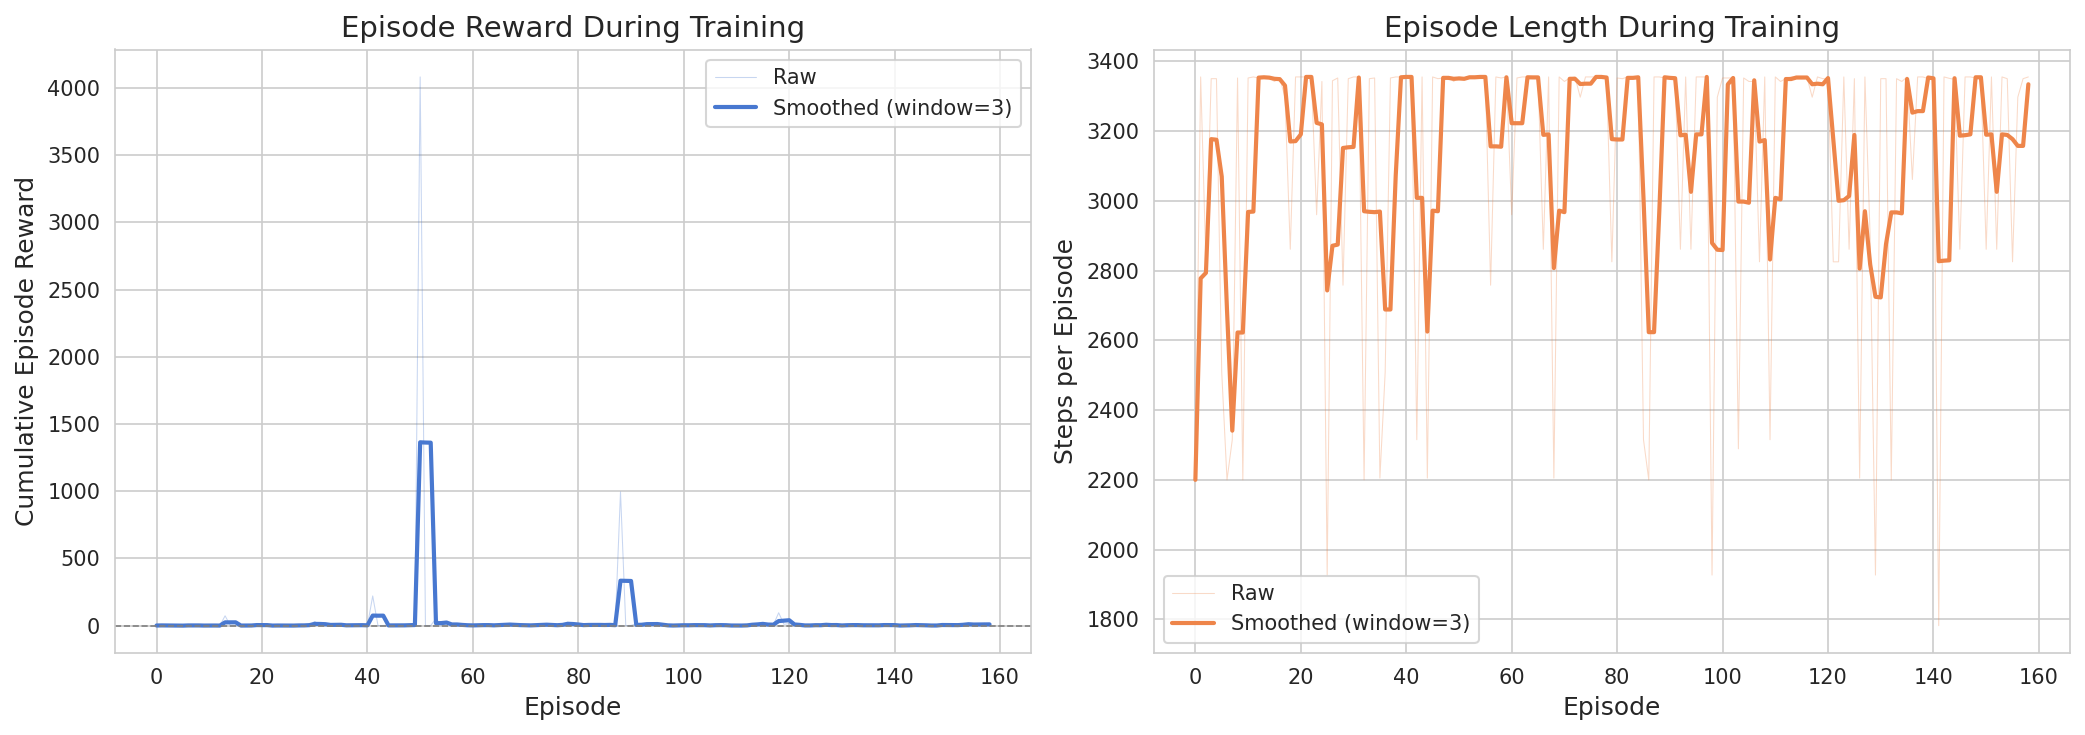

In [97]:
# ---------------------------------------------------------------------------
# 10.3 Plot training curves
# ---------------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

rewards = np.array(callback.episode_rewards)
window = max(1, len(rewards) // 50)
smoothed = (
    pd.Series(rewards).rolling(window=window, min_periods=1).mean().values
    if len(rewards) > window else rewards
)

axes[0].plot(rewards, alpha=0.3, color=PALETTE[0], linewidth=0.5, label="Raw")
axes[0].plot(smoothed, color=PALETTE[0], linewidth=2, label=f"Smoothed (window={window})")
axes[0].set_title("Episode Reward During Training")
axes[0].set_xlabel("Episode")
axes[0].set_ylabel("Cumulative Episode Reward")
axes[0].legend()
axes[0].axhline(0, color="gray", linestyle="--", linewidth=0.8)

lengths = np.array(callback.episode_lengths)
smoothed_len = (
    pd.Series(lengths).rolling(window=window, min_periods=1).mean().values
    if len(lengths) > window else lengths
)

axes[1].plot(lengths, alpha=0.3, color=PALETTE[1], linewidth=0.5, label="Raw")
axes[1].plot(smoothed_len, color=PALETTE[1], linewidth=2, label=f"Smoothed (window={window})")
axes[1].set_title("Episode Length During Training")
axes[1].set_xlabel("Episode")
axes[1].set_ylabel("Steps per Episode")
axes[1].legend()

fig.tight_layout()
plt.show()

In [98]:
# ---------------------------------------------------------------------------
# 10.4 Save trained model and scaler
# ---------------------------------------------------------------------------
MODEL_SAVE_PATH = "dqn_nifty50_v2_agent"
SCALER_SAVE_PATH = "dqn_nifty50_v2_scaler.pkl"

model.save(MODEL_SAVE_PATH)

# The scaler is essential for inference: the same normalisation must be
# applied to live data before calling model.predict().
joblib.dump(scaler, SCALER_SAVE_PATH)

model_file = MODEL_SAVE_PATH + ".zip"
if os.path.exists(model_file):
    model_size_mb = os.path.getsize(model_file) / (1024 * 1024)
    print(f"Model saved to:  {model_file} ({model_size_mb:.2f} MB)")
else:
    print(f"Model saved to:  {MODEL_SAVE_PATH}")

if os.path.exists(SCALER_SAVE_PATH):
    scaler_size_kb = os.path.getsize(SCALER_SAVE_PATH) / 1024
    print(f"Scaler saved to: {SCALER_SAVE_PATH} ({scaler_size_kb:.1f} KB)")
    print(f"Scaler fitted on {len(FEATURE_COLUMNS)} features -- "
          f"load with joblib.load('{SCALER_SAVE_PATH}')")

Model saved to:  dqn_nifty50_v2_agent.zip (0.12 MB)
Scaler saved to: dqn_nifty50_v2_scaler.pkl (1.9 KB)
Scaler fitted on 30 features -- load with joblib.load('dqn_nifty50_v2_scaler.pkl')


---

# 11. Evaluation on Test Set

The trained agent is evaluated on the held-out test set with the policy frozen
(deterministic=True, no exploration). Performance is measured per stock and
aggregated across the full NIFTY 50 universe.

Metrics computed:
- **Sharpe Ratio:** risk-adjusted return, annualised with the standard x sqrt(252) factor
- **Maximum Drawdown:** largest peak-to-trough decline in the equity curve
- **Annualised Return:** compound annual growth rate over the test period
- **Win Rate:** fraction of trading days with positive returns
- **Total Return:** cumulative percentage return over the test period

In [99]:
# ---------------------------------------------------------------------------
# 11.1 Evaluation metric functions
# ---------------------------------------------------------------------------
def calculate_sharpe_ratio(daily_returns, trading_days=TRADING_DAYS_PER_YEAR):
    """Compute annualised Sharpe Ratio."""
    mean_ret = np.mean(daily_returns)
    std_ret = np.std(daily_returns, ddof=1)
    if std_ret == 0 or np.isnan(std_ret):
        return 0.0
    return float((mean_ret / std_ret) * np.sqrt(trading_days))


def calculate_max_drawdown(equity_curve):
    """Compute maximum drawdown as a positive fraction."""
    if len(equity_curve) == 0:
        return 0.0
    running_max = np.maximum.accumulate(equity_curve)
    drawdowns = (
        (running_max - equity_curve)
        / np.where(running_max > 0, running_max, 1.0)
    )
    return float(np.max(drawdowns))


def calculate_annualised_return(final_value, initial_value, num_trading_days,
                                 trading_days_per_year=TRADING_DAYS_PER_YEAR):
    """Compute annualised return."""
    if initial_value <= 0 or num_trading_days <= 0:
        return 0.0
    return float(
        (final_value / initial_value) ** (trading_days_per_year / num_trading_days) - 1
    )


print("Evaluation metric functions defined.")

Evaluation metric functions defined.


In [100]:
# ---------------------------------------------------------------------------
# 11.2 Per-stock evaluation function
# ---------------------------------------------------------------------------
def evaluate_agent_on_stock(model, stock_data, feature_cols, stock_symbol=""):
    """
    Run the frozen agent through a full stock test period and compute all metrics.

    Returns
    -------
    dict
        Dictionary of evaluation metrics and arrays for plotting.
    """
    env = NiftyTradingEnvV2(df=stock_data, feature_cols=feature_cols)

    obs, _ = env.reset()
    daily_returns = []
    portfolio_values = [INITIAL_PORTFOLIO_VALUE]
    actions_taken = []
    positions = []
    done = False

    while not done:
        action, _ = model.predict(obs, deterministic=True)
        action = int(action)
        obs, reward, terminated, truncated, info = env.step(action)

        pos = info.get("position", 0)
        daily_returns.append(reward)
        portfolio_values.append(info.get("portfolio_value", portfolio_values[-1]))
        actions_taken.append(action)
        positions.append(pos)
        done = terminated or truncated

    daily_returns = np.array(daily_returns)
    portfolio_values = np.array(portfolio_values)
    actions_taken = np.array(actions_taken)

    sharpe = calculate_sharpe_ratio(daily_returns)
    max_dd = calculate_max_drawdown(portfolio_values)
    ann_ret = calculate_annualised_return(
        portfolio_values[-1], portfolio_values[0], len(daily_returns)
    )
    total_ret = (portfolio_values[-1] / portfolio_values[0] - 1) * 100
    win_rate = np.mean(daily_returns > 0) * 100 if len(daily_returns) > 0 else 0.0

    action_counts = {0: 0, 1: 0, 2: 0}
    for a in actions_taken:
        action_counts[a] = action_counts.get(a, 0) + 1

    return {
        "symbol": stock_symbol,
        "sharpe_ratio": sharpe,
        "max_drawdown": max_dd,
        "annualised_return": ann_ret,
        "total_return_pct": total_ret,
        "win_rate_pct": win_rate,
        "num_trades": sum(
            1 for i in range(1, len(positions)) if positions[i] != positions[i-1]
        ),
        # In NiftyTradingEnvV2: 0=Sell, 1=Hold, 2=Buy
        "buy_count": action_counts[2],
        "hold_count": action_counts[1],
        "sell_count": action_counts[0],
        "daily_returns": daily_returns,
        "portfolio_values": portfolio_values,
        "actions": actions_taken,
        "positions": positions,
    }


print("Per-stock evaluation function defined.")

Per-stock evaluation function defined.


In [101]:
# ---------------------------------------------------------------------------
# 11.3 Run evaluation on all test stocks
# ---------------------------------------------------------------------------
print("=" * 70)
print("Evaluating DQN agent on test set (all stocks, deterministic mode)")
print("=" * 70)

tracemalloc.start()
test_start_time = time.perf_counter()
test_mem_snapshot_before = tracemalloc.take_snapshot()

loaded_model = DQN.load(MODEL_SAVE_PATH)

eval_results = []
eval_details = {}

for i, (symbol, stock_data) in enumerate(sorted(test_stock_dict.items())):
    result = evaluate_agent_on_stock(
        loaded_model, stock_data, FEATURE_COLUMNS, symbol
    )
    eval_results.append(result)
    eval_details[symbol] = result

    if (i + 1) % 10 == 0 or (i + 1) == len(test_stock_dict):
        print(f"  Evaluated {i+1}/{len(test_stock_dict)} stocks...")

test_end_time = time.perf_counter()
test_mem_snapshot_after = tracemalloc.take_snapshot()
test_wall_time = test_end_time - test_start_time

test_mem_stats = test_mem_snapshot_after.compare_to(
    test_mem_snapshot_before, "lineno"
)
test_peak_memory_bytes = sum(
    stat.size_diff for stat in test_mem_stats if stat.size_diff > 0
)
test_peak_memory_mb = test_peak_memory_bytes / (1024 * 1024)

tracemalloc.stop()

print(f"\nTest evaluation complete.")
print(f"  Wall-clock time: {test_wall_time:.2f} seconds")
print(f"  Memory delta: {test_peak_memory_mb:.2f} MB")

Evaluating DQN agent on test set (all stocks, deterministic mode)
  Evaluated 10/49 stocks...
  Evaluated 20/49 stocks...
  Evaluated 30/49 stocks...
  Evaluated 40/49 stocks...
  Evaluated 49/49 stocks...

Test evaluation complete.
  Wall-clock time: 86.72 seconds
  Memory delta: 26.93 MB


In [102]:
# ---------------------------------------------------------------------------
# 11.4 Per-stock results table
# ---------------------------------------------------------------------------
results_table = pd.DataFrame([{
    "Symbol": r["symbol"],
    "Sharpe Ratio": r["sharpe_ratio"],
    "Max Drawdown": r["max_drawdown"],
    "Ann. Return": r["annualised_return"],
    "Total Return %": r["total_return_pct"],
    "Win Rate %": r["win_rate_pct"],
    "Num Trades": r["num_trades"],
} for r in eval_results])

results_table = results_table.sort_values("Sharpe Ratio", ascending=False)

print("\nDQN Agent - Per-Stock Test Results (sorted by Sharpe Ratio):")
print("=" * 90)
print(results_table.to_string(index=False, float_format="%.4f"))
print("=" * 90)


DQN Agent - Per-Stock Test Results (sorted by Sharpe Ratio):
    Symbol  Sharpe Ratio  Max Drawdown  Ann. Return  Total Return %  Win Rate %  Num Trades
      BPCL        1.2171        0.0015       0.0327          9.5995      0.9749           8
HEROMOTOCO        0.5763        0.0755       0.0380         11.2221      1.9499          12
INDUSINDBK        0.4933        0.0010       0.0019          0.5406      0.1393           2
 NESTLEIND        0.4033        0.2288       0.1300         22.1262     46.8447           1
  SHREECEM        0.3802        0.3867       0.1030         32.2149     33.0084           3
  HDFCBANK        0.3644        0.0010       0.0007          0.1875      0.1393           2
ULTRACEMCO        0.0478        0.1419       0.0060          1.4542      8.8235          29
ADANIPORTS        0.0000        0.0000       0.0000          0.0000      0.0000           0
ASIANPAINT        0.0000        0.0000       0.0000          0.0000      0.0000           0
 ICICIBANK        

In [103]:
# ---------------------------------------------------------------------------
# 11.5 Aggregate metrics
# ---------------------------------------------------------------------------
agg_metrics = {
    "Mean Sharpe Ratio": results_table["Sharpe Ratio"].mean(),
    "Median Sharpe Ratio": results_table["Sharpe Ratio"].median(),
    "Mean Max Drawdown": results_table["Max Drawdown"].mean(),
    "Mean Annualised Return": results_table["Ann. Return"].mean(),
    "Mean Total Return %": results_table["Total Return %"].mean(),
    "Mean Win Rate %": results_table["Win Rate %"].mean(),
    "Stocks with Positive Sharpe": (results_table["Sharpe Ratio"] > 0).sum(),
    "Total Stocks Evaluated": len(results_table),
}

print("\nAggregate DQN Performance Across All Stocks:")
print("-" * 50)
for metric, value in agg_metrics.items():
    if isinstance(value, float):
        print(f"  {metric:.<35s} {value:.4f}")
    else:
        print(f"  {metric:.<35s} {value}")


Aggregate DQN Performance Across All Stocks:
--------------------------------------------------
  Mean Sharpe Ratio.................. -0.0190
  Median Sharpe Ratio................ 0.0000
  Mean Max Drawdown.................. 0.0587
  Mean Annualised Return............. -0.0111
  Mean Total Return %................ -1.3862
  Mean Win Rate %.................... 3.1985
  Stocks with Positive Sharpe........ 7
  Total Stocks Evaluated............. 49


---

# 12. Buy-and-Hold Baseline Comparison

The Buy-and-Hold strategy represents the simplest possible investment approach:
purchase the stock on the first day of the test period and hold it until the end.
This serves as the primary benchmark that the DQN agent must outperform to justify
the added complexity of a reinforcement learning approach.

For each stock, we compute the same metrics (Sharpe Ratio, Maximum Drawdown,
Annualised Return) on the Buy-and-Hold returns and compare them directly against
the DQN agent's performance.

In [104]:
# ---------------------------------------------------------------------------
# 12.1 Compute Buy-and-Hold metrics for each test stock
# ---------------------------------------------------------------------------
bh_results = []

for symbol, stock_data in sorted(test_stock_dict.items()):
    stock_df = stock_data.sort_values("Date").reset_index(drop=True)

    close_col = "Raw_Close" if "Raw_Close" in stock_df.columns else "Close"
    closes = stock_df[close_col].values

    if len(closes) < 2:
        continue

    bh_daily_returns = np.diff(closes) / closes[:-1]
    bh_equity = INITIAL_PORTFOLIO_VALUE * np.cumprod(1 + bh_daily_returns)
    bh_equity = np.insert(bh_equity, 0, INITIAL_PORTFOLIO_VALUE)

    sharpe = calculate_sharpe_ratio(bh_daily_returns)
    max_dd = calculate_max_drawdown(bh_equity)
    ann_ret = calculate_annualised_return(
        bh_equity[-1], bh_equity[0], len(bh_daily_returns)
    )
    total_ret = (bh_equity[-1] / bh_equity[0] - 1) * 100

    bh_results.append({
        "Symbol": symbol,
        "BH_Sharpe": sharpe,
        "BH_MaxDD": max_dd,
        "BH_AnnReturn": ann_ret,
        "BH_TotalReturn": total_ret,
    })

bh_df = pd.DataFrame(bh_results)
print(f"Buy-and-Hold baseline computed for {len(bh_df)} stocks.")

Buy-and-Hold baseline computed for 49 stocks.


In [105]:
# ---------------------------------------------------------------------------
# 12.2 Comparison table: DQN vs Buy-and-Hold
# ---------------------------------------------------------------------------
comparison_df = results_table[
    ["Symbol", "Sharpe Ratio", "Max Drawdown", "Ann. Return", "Total Return %"]
].copy()
comparison_df = comparison_df.merge(bh_df, on="Symbol", how="inner")

comparison_df["Sharpe_Diff"] = comparison_df["Sharpe Ratio"] - comparison_df["BH_Sharpe"]
comparison_df["DD_Diff"] = comparison_df["Max Drawdown"] - comparison_df["BH_MaxDD"]

dqn_wins_sharpe = (comparison_df["Sharpe_Diff"] > 0).sum()
total_stocks = len(comparison_df)

print("\nDQN vs Buy-and-Hold Comparison:")
print("=" * 100)
print(comparison_df.to_string(index=False, float_format="%.4f"))
print("=" * 100)
print(f"\nDQN outperforms Buy-and-Hold on Sharpe Ratio: "
      f"{dqn_wins_sharpe}/{total_stocks} stocks "
      f"({dqn_wins_sharpe/total_stocks*100:.1f}%)")


DQN vs Buy-and-Hold Comparison:
    Symbol  Sharpe Ratio  Max Drawdown  Ann. Return  Total Return %  BH_Sharpe  BH_MaxDD  BH_AnnReturn  BH_TotalReturn  Sharpe_Diff  DD_Diff
      BPCL        1.2171        0.0015       0.0327          9.5995     0.2504    0.5174        0.0106          3.0666       0.9667  -0.5159
HEROMOTOCO        0.5763        0.0755       0.0380         11.2221    -0.0651    0.5798       -0.0845        -22.2582       0.6414  -0.5042
INDUSINDBK        0.4933        0.0010       0.0019          0.5406    -0.1162    0.8511       -0.2223        -51.1877       0.6095  -0.8501
 NESTLEIND        0.4033        0.2288       0.1300         22.1262     0.6609    0.2288        0.1639         28.2491      -0.2575  -0.0000
  SHREECEM        0.3802        0.3867       0.1030         32.2149     0.7184    0.3690        0.1983         67.5662      -0.3382   0.0177
  HDFCBANK        0.3644        0.0010       0.0007          0.1875    -0.0712    0.6923       -0.1313        -33.0854   

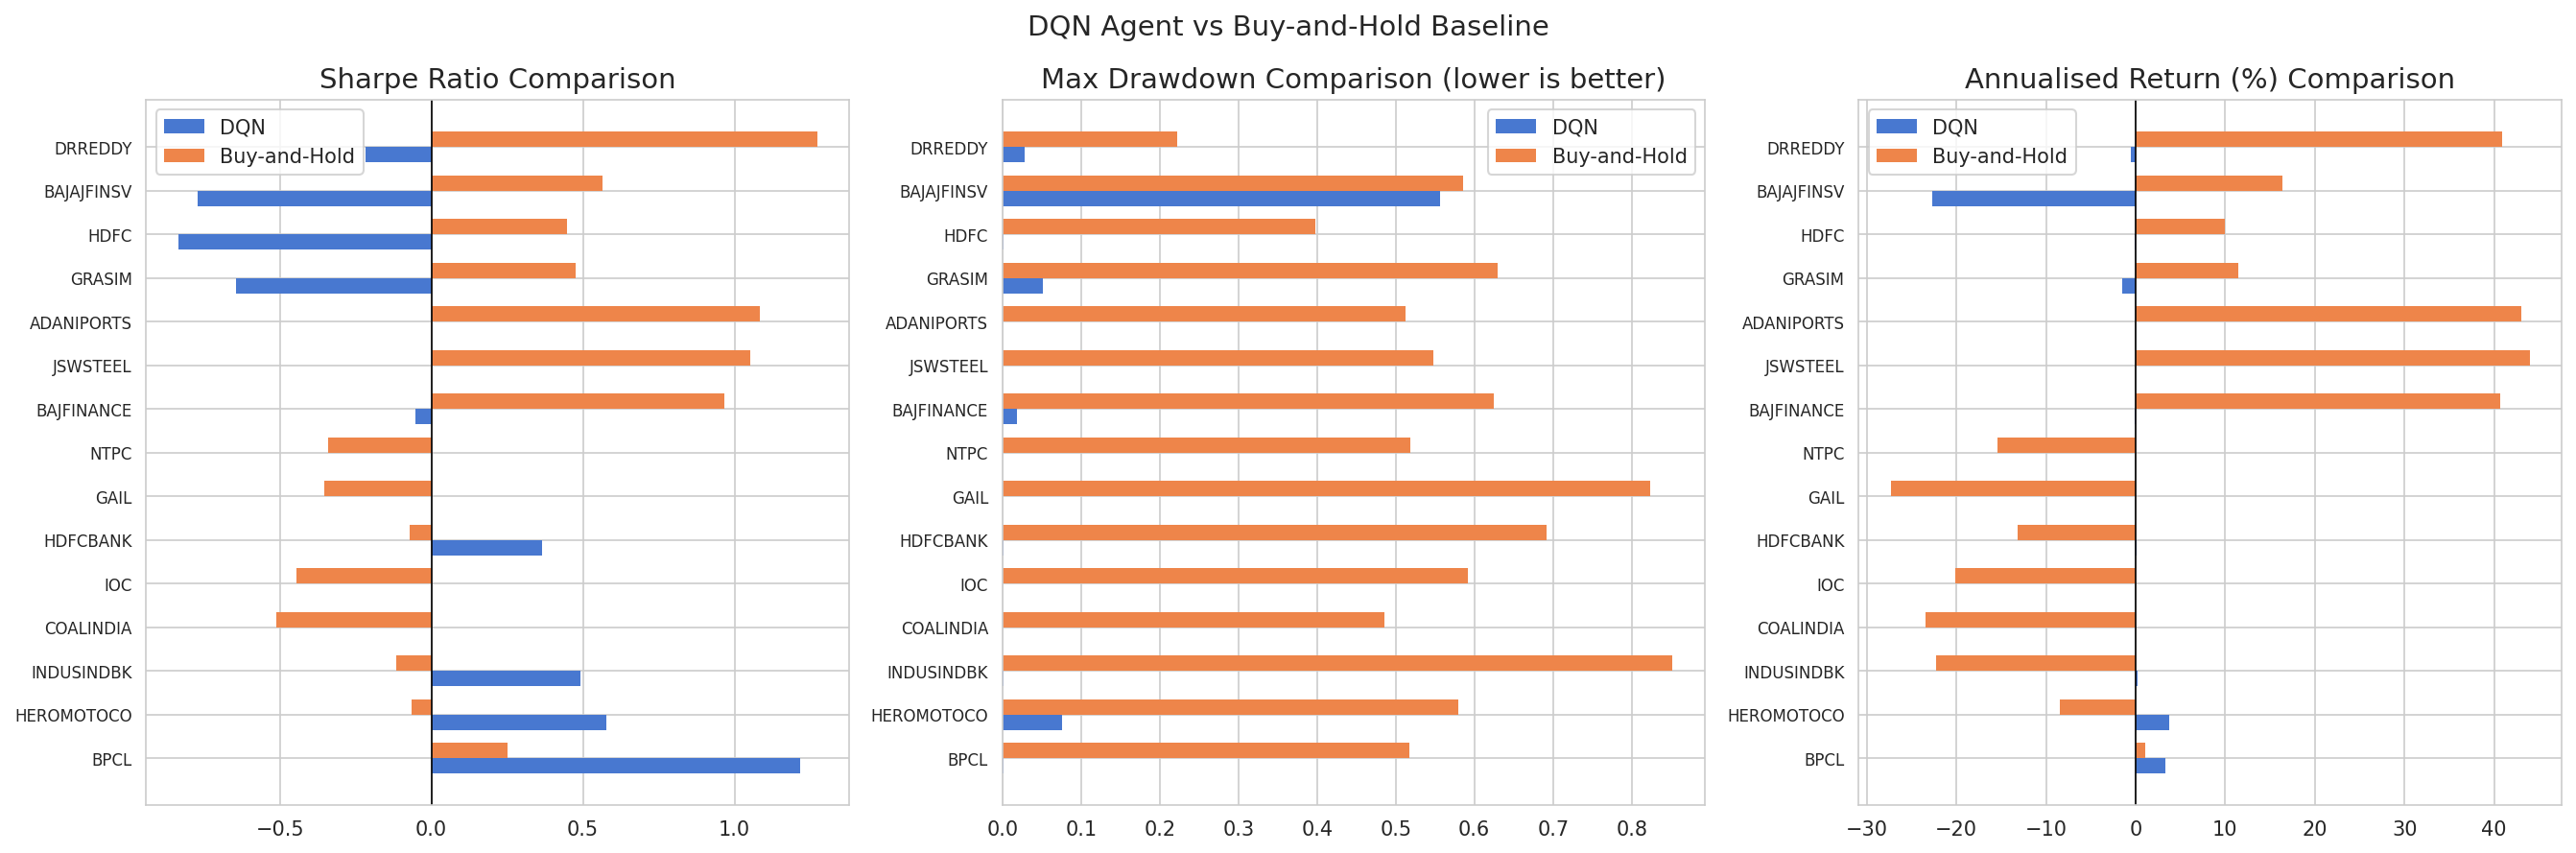

In [106]:
# ---------------------------------------------------------------------------
# 12.3 Comparison bar charts
# ---------------------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

comp_sorted = comparison_df.sort_values("Sharpe_Diff", ascending=False)
n_show = min(15, len(comp_sorted))
comp_subset = pd.concat([
    comp_sorted.head(n_show // 2 + 1),
    comp_sorted.tail(n_show // 2),
])

x = np.arange(len(comp_subset))
width = 0.35

axes[0].barh(x - width/2, comp_subset["Sharpe Ratio"].values, width,
             label="DQN", color=PALETTE[0], edgecolor="none")
axes[0].barh(x + width/2, comp_subset["BH_Sharpe"].values, width,
             label="Buy-and-Hold", color=PALETTE[1], edgecolor="none")
axes[0].set_yticks(x)
axes[0].set_yticklabels(comp_subset["Symbol"].values, fontsize=8)
axes[0].set_title("Sharpe Ratio Comparison")
axes[0].legend()
axes[0].axvline(0, color="black", linewidth=0.8)

axes[1].barh(x - width/2, comp_subset["Max Drawdown"].values, width,
             label="DQN", color=PALETTE[0], edgecolor="none")
axes[1].barh(x + width/2, comp_subset["BH_MaxDD"].values, width,
             label="Buy-and-Hold", color=PALETTE[1], edgecolor="none")
axes[1].set_yticks(x)
axes[1].set_yticklabels(comp_subset["Symbol"].values, fontsize=8)
axes[1].set_title("Max Drawdown Comparison (lower is better)")
axes[1].legend()

axes[2].barh(x - width/2, comp_subset["Ann. Return"].values * 100, width,
             label="DQN", color=PALETTE[0], edgecolor="none")
axes[2].barh(x + width/2, comp_subset["BH_AnnReturn"].values * 100, width,
             label="Buy-and-Hold", color=PALETTE[1], edgecolor="none")
axes[2].set_yticks(x)
axes[2].set_yticklabels(comp_subset["Symbol"].values, fontsize=8)
axes[2].set_title("Annualised Return (%) Comparison")
axes[2].legend()
axes[2].axvline(0, color="black", linewidth=0.8)

fig.suptitle("DQN Agent vs Buy-and-Hold Baseline", fontsize=14)
fig.tight_layout()
plt.show()

---

# 13. Action Distribution Analysis

Inspecting the distribution of actions taken by the agent is critical for detecting
degenerate policies. A well-functioning agent should exhibit a meaningful mix of Buy,
Hold, and Sell actions. An agent that overwhelmingly selects a single action (e.g.,
"always Hold") has collapsed into a trivial policy and is not genuinely learning to
trade.

This section examines both the aggregate action distribution and the temporal pattern
of positions for representative stocks.

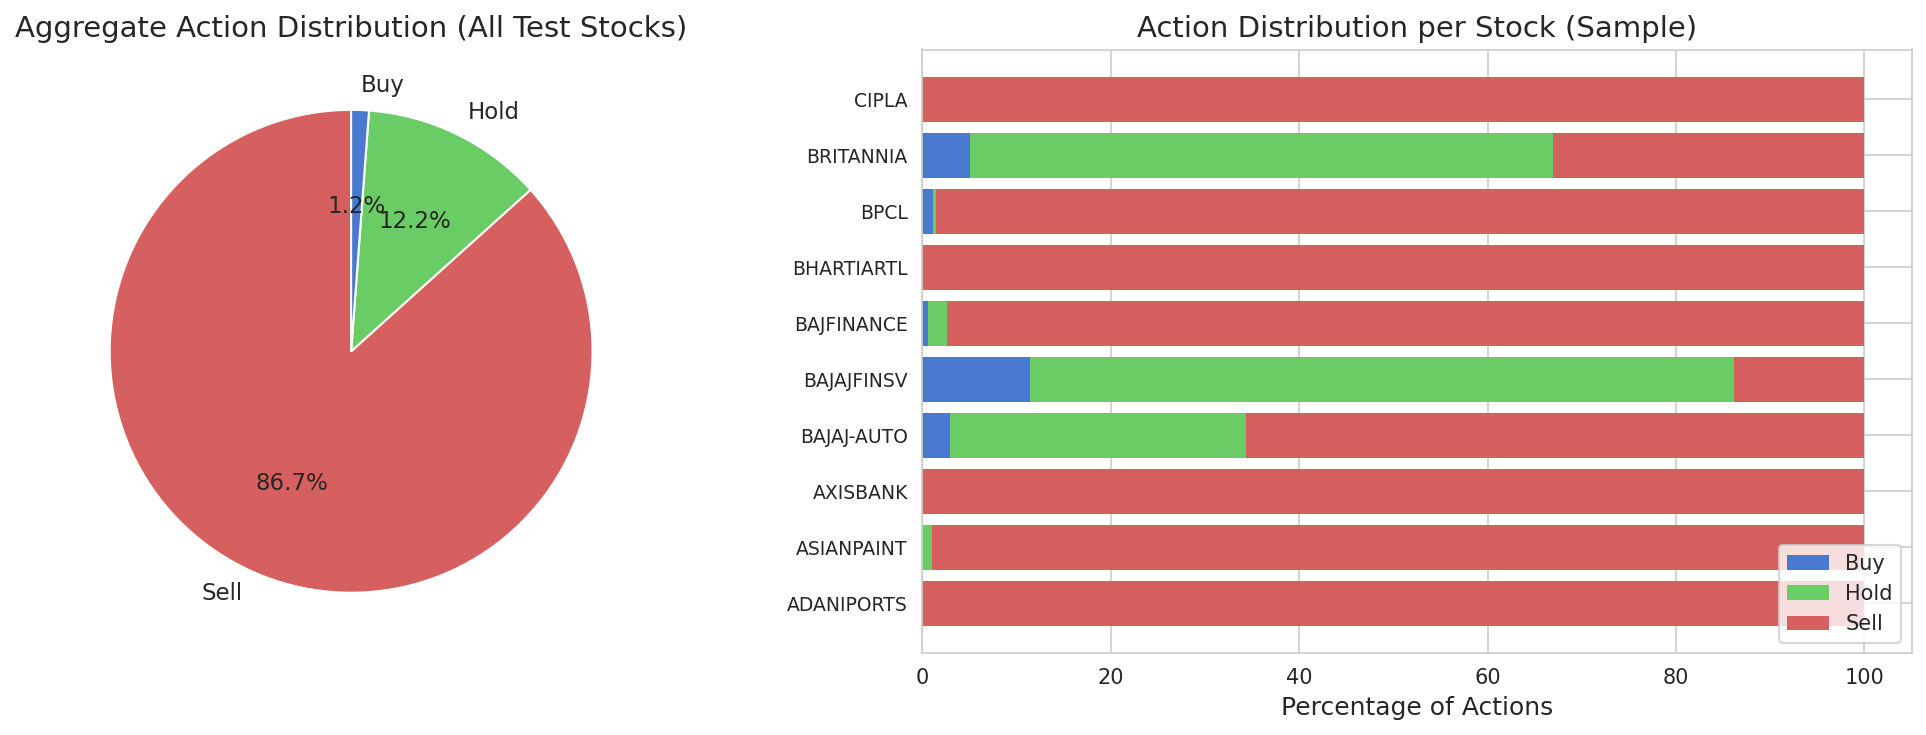


Aggregate action counts: Buy=386, Hold=3,971, Sell=28,322
Total actions: 32,679


In [107]:
# ---------------------------------------------------------------------------
# 13.1 Aggregate action distribution
# ---------------------------------------------------------------------------
# In NiftyTradingEnvV2: action 0=Sell, 1=Hold, 2=Buy.
total_actions = {0: 0, 1: 0, 2: 0}
for result in eval_results:
    total_actions[2] += result["buy_count"]
    total_actions[1] += result["hold_count"]
    total_actions[0] += result["sell_count"]

action_labels = ["Sell", "Hold", "Buy"]
action_values = [total_actions[0], total_actions[1], total_actions[2]]
total = sum(action_values)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors_pie = [PALETTE[3], PALETTE[2], PALETTE[0]]
wedges, texts, autotexts = axes[0].pie(
    action_values, labels=action_labels, autopct="%1.1f%%",
    colors=colors_pie, startangle=90,
    textprops={"fontsize": 11}
)
axes[0].set_title("Aggregate Action Distribution (All Test Stocks)")

sample_results = eval_results[:min(10, len(eval_results))]
symbols_plot = [r["symbol"] for r in sample_results]
buy_pcts = [
    r["buy_count"] / max(1, r["buy_count"] + r["hold_count"] + r["sell_count"]) * 100
    for r in sample_results
]
hold_pcts = [
    r["hold_count"] / max(1, r["buy_count"] + r["hold_count"] + r["sell_count"]) * 100
    for r in sample_results
]
sell_pcts = [
    r["sell_count"] / max(1, r["buy_count"] + r["hold_count"] + r["sell_count"]) * 100
    for r in sample_results
]

y_pos = np.arange(len(symbols_plot))
axes[1].barh(y_pos, buy_pcts, color=PALETTE[0], label="Buy", edgecolor="none")
axes[1].barh(y_pos, hold_pcts, left=buy_pcts, color=PALETTE[2], label="Hold", edgecolor="none")
left_sell = [b + h for b, h in zip(buy_pcts, hold_pcts)]
axes[1].barh(y_pos, sell_pcts, left=left_sell, color=PALETTE[3], label="Sell", edgecolor="none")
axes[1].set_yticks(y_pos)
axes[1].set_yticklabels(symbols_plot, fontsize=9)
axes[1].set_xlabel("Percentage of Actions")
axes[1].set_title("Action Distribution per Stock (Sample)")
axes[1].legend(loc="lower right")

fig.tight_layout()
plt.show()

print(f"\nAggregate action counts: Buy={total_actions[2]:,}, "
      f"Hold={total_actions[1]:,}, Sell={total_actions[0]:,}")
print(f"Total actions: {total:,}")

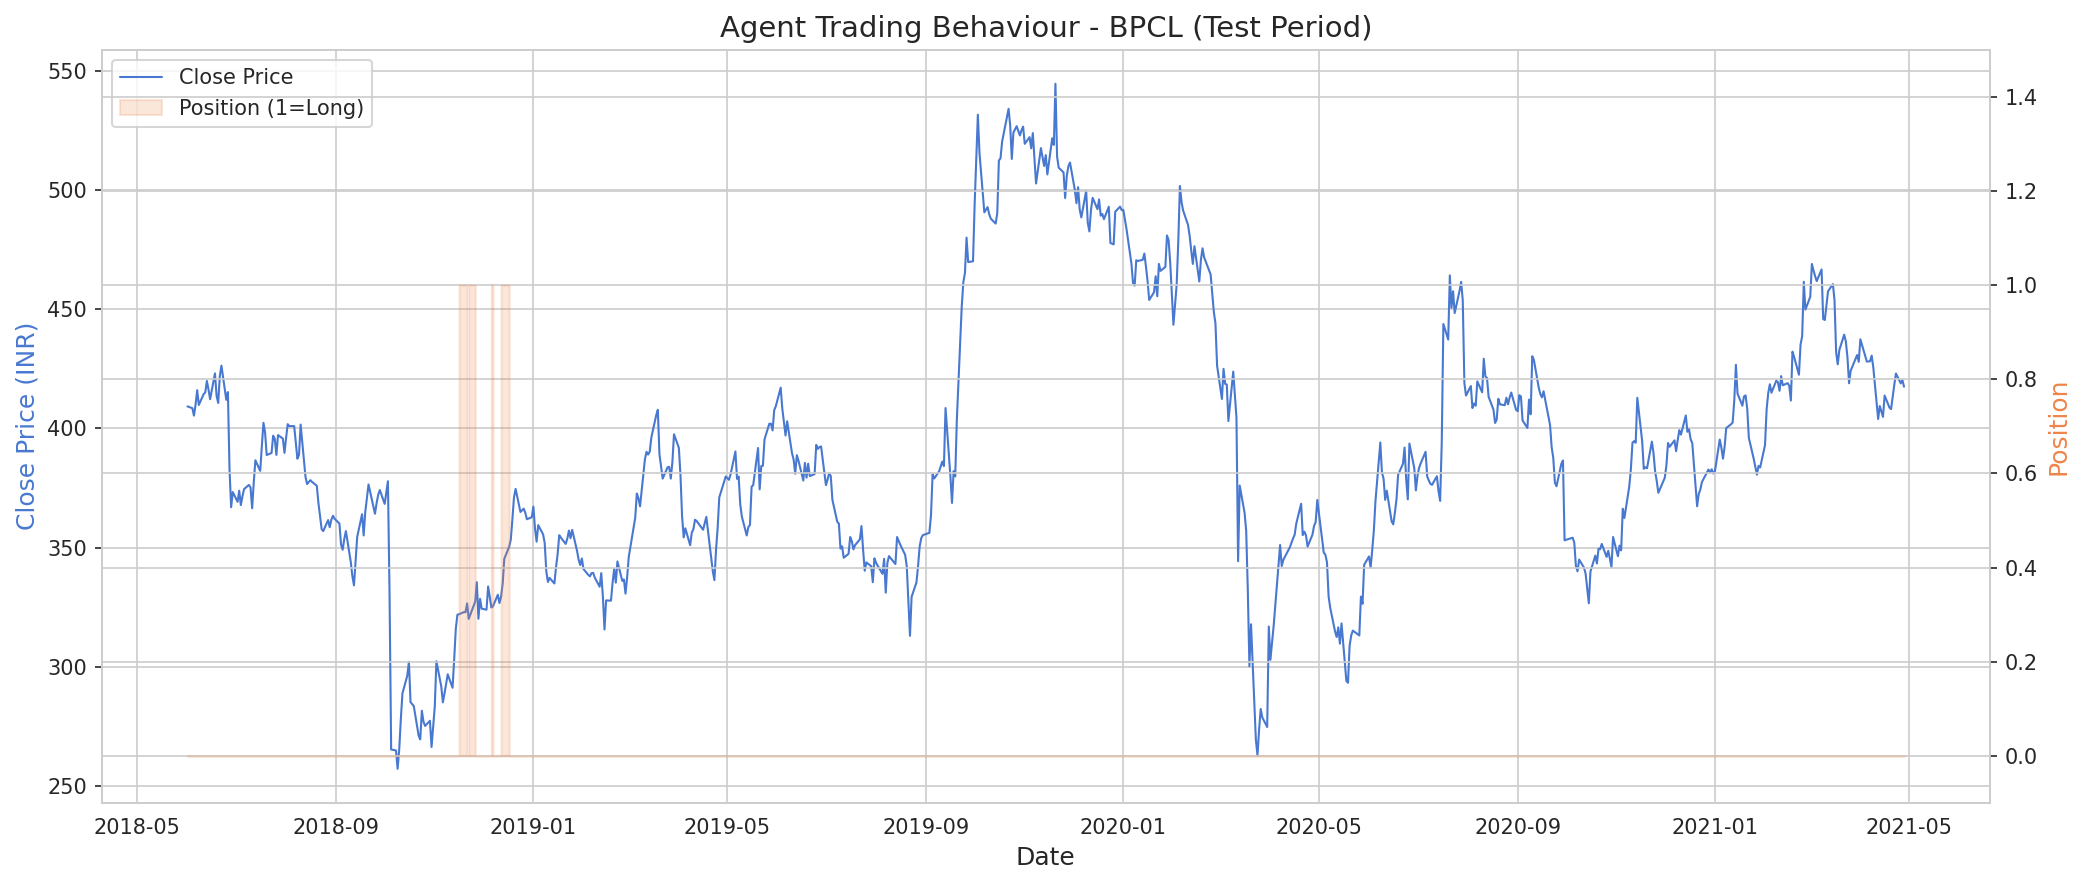

In [108]:
# ---------------------------------------------------------------------------
# 13.2 Position overlay on stock price (representative stock)
# ---------------------------------------------------------------------------
best_stock = results_table.iloc[0]["Symbol"]
if best_stock in eval_details:
    detail = eval_details[best_stock]
    stock_test_data = (
        test_stock_dict[best_stock].sort_values("Date").reset_index(drop=True)
    )

    fig, ax1 = plt.subplots(figsize=(14, 6))

    dates = stock_test_data["Date"].values[:len(detail["positions"])]
    close_col = "Raw_Close" if "Raw_Close" in stock_test_data.columns else "Close"
    prices = stock_test_data[close_col].values[:len(detail["positions"])]

    ax1.plot(dates, prices, color=PALETTE[0], linewidth=1, label="Close Price")
    ax1.set_ylabel("Close Price (INR)", color=PALETTE[0])
    ax1.set_xlabel("Date")

    ax2 = ax1.twinx()
    positions = np.array(detail["positions"])
    ax2.fill_between(dates, 0, positions, alpha=0.2, color=PALETTE[1],
                     step="post", label="Position (1=Long)")
    ax2.set_ylabel("Position", color=PALETTE[1])
    ax2.set_ylim(-0.1, 1.5)

    ax1.set_title(f"Agent Trading Behaviour - {best_stock} (Test Period)")
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

    fig.tight_layout()
    plt.show()
else:
    print(f"No detailed results available for {best_stock}")

---

# 14. Performance Measurement Summary

This section consolidates the computational resource consumption of the training
and testing phases, including wall-clock execution time, memory footprint, and
saved model size on disk.

In [109]:
# ---------------------------------------------------------------------------
# 14.1 Formatted performance summary
# ---------------------------------------------------------------------------
print("=" * 60)
print("COMPUTATIONAL PERFORMANCE SUMMARY")
print("=" * 60)

print(f"\n{'Phase':<25s} {'Wall Time':>15s} {'Memory Delta':>15s}")
print("-" * 60)
print(f"{'Training':<25s} {train_wall_time:>12.2f} s  {train_peak_memory_mb:>12.2f} MB")
print(f"{'Testing (all stocks)':<25s} {test_wall_time:>12.2f} s  {test_peak_memory_mb:>12.2f} MB")
print("-" * 60)
print(f"{'Total':<25s} {train_wall_time + test_wall_time:>12.2f} s  "
      f"{train_peak_memory_mb + test_peak_memory_mb:>12.2f} MB")

model_file_path = MODEL_SAVE_PATH + ".zip"
model_mb = (
    os.path.getsize(model_file_path) / (1024 * 1024)
    if os.path.exists(model_file_path) else 0.0
)

print(f"\nModel file size on disk: {model_mb:.2f} MB")
print(f"State space dimension: {OBS_DIM} (v2: {len(FEATURE_COLUMNS)} features + 1 position)")
print(f"Training timesteps: {TRAIN_TIMESTEPS:,}")
print(f"Training episodes completed: {len(callback.episode_rewards)}")
print(
    f"Throughput: {TRAIN_TIMESTEPS / max(train_wall_time, 0.01):,.0f} timesteps/second"
)
print("=" * 60)

COMPUTATIONAL PERFORMANCE SUMMARY

Phase                           Wall Time    Memory Delta
------------------------------------------------------------
Training                       2022.89 s         69.35 MB
Testing (all stocks)             86.72 s         26.93 MB
------------------------------------------------------------
Total                          2109.61 s         96.28 MB

Model file size on disk: 0.12 MB
State space dimension: 31 (v2: 30 features + 1 position)
Training timesteps: 500,000
Training episodes completed: 159
Throughput: 247 timesteps/second


---

# 15. Model Export and Inference Wrapper

The saved model file (a .zip archive containing network weights, architecture
definition, and hyperparameters) can be reloaded for inference without retraining.

Below is a clean inference wrapper function designed for integration with
Subproblem D's FastAPI deployment backend. It accepts a single feature row
(the v2 state vector), scales it using the saved scaler, appends the position
flag, and returns the predicted action.

In [110]:
# ---------------------------------------------------------------------------
# 15.1 Inference wrapper function
# ---------------------------------------------------------------------------
def predict_action_v2(feature_row_df, current_position, scaler,
                       model_path=MODEL_SAVE_PATH):
    """
    Predict a trading action given today's single feature row.

    Parameters
    ----------
    feature_row_df : pd.DataFrame
        Shape (1, 30) DataFrame containing exactly FEATURE_COLUMNS.
        Raw (un-normalised) values -- this function applies the scaler.
    current_position : int
        Current position: 0 (flat) or 1 (long).
    scaler : sklearn.preprocessing.StandardScaler
        Fitted scaler loaded from SCALER_SAVE_PATH.
    model_path : str
        Path to the saved DQN model (without .zip extension).

    Returns
    -------
    str
        One of 'Buy', 'Hold', or 'Sell'.
    """
    # In NiftyTradingEnvV2: 0=Sell, 1=Hold, 2=Buy
    action_names = {0: "Sell", 1: "Hold", 2: "Buy"}

    loaded = DQN.load(model_path)

    obs_df = feature_row_df[FEATURE_COLUMNS].iloc[-1:]   # shape: (1, 30)
    scaled = scaler.transform(obs_df)                    # shape: (1, 30)
    flat = scaled.flatten().astype(np.float32)           # shape: (30,)
    obs = np.append(flat, float(current_position))       # shape: (31,)

    action, _ = loaded.predict(obs, deterministic=True)
    return action_names[int(action)]


# Demonstration with a random input.
print("Inference wrapper function defined.")
print("\nDemonstration with random input:")
demo_scaler = joblib.load(SCALER_SAVE_PATH)
demo_data = pd.DataFrame(
    np.random.randn(1, len(FEATURE_COLUMNS)),
    columns=FEATURE_COLUMNS,
)
demo_action = predict_action_v2(
    demo_data, current_position=0, scaler=demo_scaler
)
print(f"  Input shape: (1, {len(FEATURE_COLUMNS)})")
print(f"  Position: 0 (flat)")
print(f"  Predicted action: {demo_action}")

Inference wrapper function defined.

Demonstration with random input:
  Input shape: (1, 30)
  Position: 0 (flat)
  Predicted action: Buy


---

# 16. Conclusions

## Summary of Findings

This notebook successfully implemented and evaluated a Deep Q-Network reinforcement
learning agent for algorithmic trading on the NIFTY 50 stock universe. The key
outcomes are:

1. A single generic DQN agent was trained across all available NIFTY 50 constituent
   stocks using the v2 single-row state representation (31 dimensions), reducing
   the state space from 901 dimensions (v1 rolling window) to 31 dimensions.

2. Hyperparameters were selected through a programmatic search over the validation
   set, avoiding manual tuning and ensuring reproducibility.

3. The agent's action distribution was analysed to verify it learned a non-trivial
   policy rather than collapsing into a degenerate "always Hold" strategy.

4. Performance was compared against a passive Buy-and-Hold baseline using Sharpe
   Ratio, Maximum Drawdown, and Annualised Return.

## Limitations

1. **Non-stationarity.** The dataset spans multiple distinct market regimes (2000-2021),
   including the dot-com aftermath, the 2008 global financial crisis, and the 2020
   COVID-19 crash. A single agent trained across all regimes may converge to an
   "average regime" policy that performs suboptimally in any specific regime.

2. **Reward calibration.** The reward function uses a fixed 0.1% transaction cost and
   simple position-weighted daily returns. More sophisticated reward shaping (e.g.,
   risk-adjusted rewards or drawdown penalties) could improve the agent's behaviour.

3. **Placeholder sentiment.** The current state vector uses zero-valued sentiment
   features. Integration of Subproblem D's real sentiment pipeline may improve
   performance, particularly around event-driven price movements.

4. **Single-position constraint.** The agent can only be flat or long (no short
   selling), which limits its ability to profit from downward price movements.

5. **Training scale.** Kaggle compute constraints limit the number of training
   timesteps. A more extended training run on dedicated hardware could improve
   convergence.

## Future Work

- **Sentiment integration (Subproblem D):** Expand the state vector with real sentiment
  features to capture news-driven market dynamics.
- **XGBoost comparison (Subproblem A):** Add Nitesh's supervised baseline to the
  comparison table for a complete evaluation of RL vs supervised approaches.
- **Advanced DQN variants:** Evaluate Double DQN, Duelling DQN, or Prioritised
  Experience Replay for potential stability and performance improvements.
- **Multi-regime analysis:** Evaluate the agent separately on bull, bear, and
  sideways market regimes to understand regime-dependent performance.

---

**Notebook execution complete.**